# Looking at the results!

Ok, we have trained a ANP, and now want to see how well it does on predicting things. There are a few tests that we can run:

1. On the left out set that wasnt used in the training
2. On the 1P set
3. On the CV set


So we want to do this here while also just demonstrating the api for using the network

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from anp_emulator import Emulator, build_diagnostics_report, plot_coverage_curve, plot_residual_vs_radius
import scienceplots
plt.style.use(['science','notebook'])



In the trianing, I trained to predict 4 fields. So each generation will include these four fields

In [2]:
RUN_DIR = Path('anp_training_runs/anp_all_profiles_20260317_034453') # this is the best training so far
# RUN_DIR = Path('anp_training_runs/anp_all_profiles_20260318_085927') # This is the vanilla training, no bells or whistles

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

emu = Emulator.from_run_dir(RUN_DIR, device=DEVICE)
print(emu.available_fields())

['gas_density', 'temperature', 'pressure', 'metallicity']


## Build Inputs

`theta` can be either shape `(35,)` or `(n_halo, 35)`. Lets start with just loading in the data

In [3]:
theta_dim = emu.theta_dim
sb35_param_csv = Path('/mnt/home/mlee1/50Mpc_boxes/data/param_df.csv')
sb35_theta_df = pd.read_csv(sb35_param_csv)
oneP_param_csv = Path('/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/1P/CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt')
oneP_theta_df = pd.read_csv(oneP_param_csv, sep=r'\s+', engine='python')
oneP_theta_df = oneP_theta_df.rename(columns={'#Name': 'tag'})
fiducial_params = oneP_theta_df[oneP_theta_df['tag'] == '1P_p1_0'].iloc[0, 1:-1].to_numpy()

Now we can define radial bins and some masses in M500

In [4]:
M = np.array([1e13, 3e13, 1e14], dtype=np.float32)
r_bins = np.geomspace(0.03, 10, 51).astype(np.float32)
fields = emu.available_fields()
pred = emu.predict(
    theta=fiducial_params,
    M=M,
    r_bins=r_bins,
    field=fields,
    n_samples=100
)

Pred then has a few returns. The mean, aleatoric uncertainty and epistemic uncertainty, and total std

If we have done things correctly the aleatoric uncertainty should be representative of the cosmic variance... I think

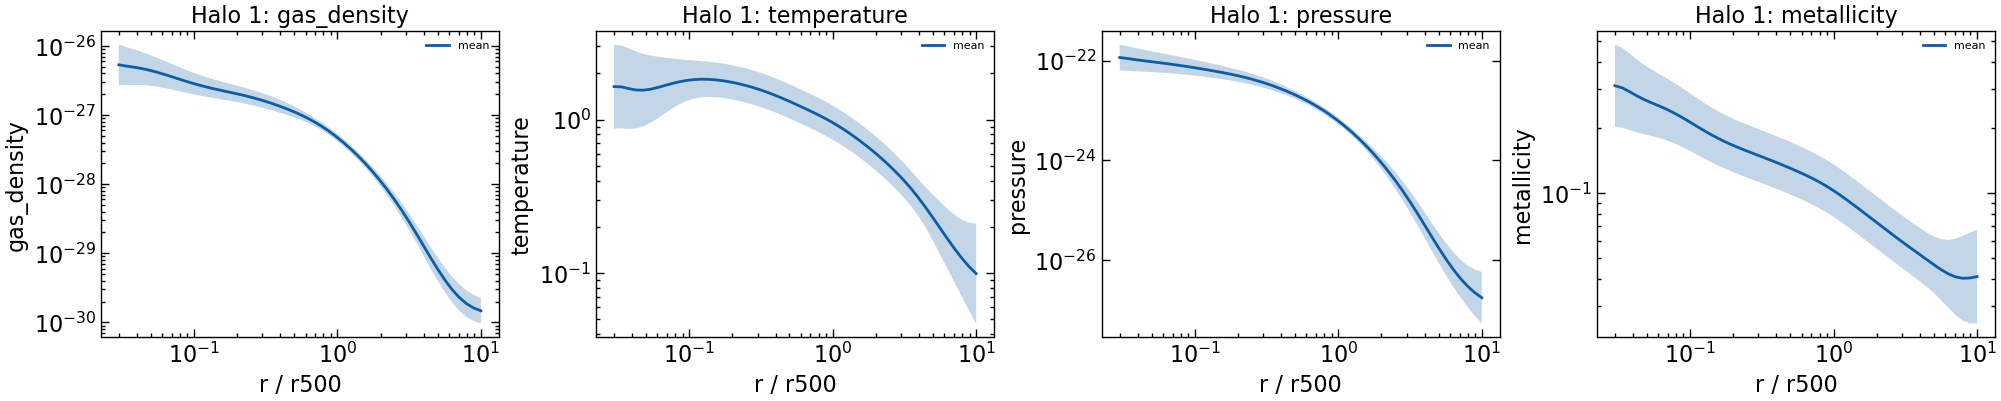

In [5]:
# Plot one halo's predicted radial profiles with 1-sigma uncertainty bands
halo_index = 1

n_fields = len(pred.field_names)
fig, axes = plt.subplots(1, n_fields, figsize=(5.0 * n_fields, 4.0), constrained_layout=True)
if n_fields == 1:
    axes = [axes]

ln10 = np.log(10.0)
tiny = np.finfo(np.float64).tiny

for j, name in enumerate(pred.field_names):
    mu = pred.mean[halo_index, :, j]
    sd = pred.total_std[halo_index, :, j]
    ax = axes[j]
    ax.plot(r_bins, mu, lw=2, label='mean')

    if np.all(mu > 0):
        sigma_log = sd / np.maximum(ln10 * mu, tiny)
        lo = mu * np.power(10.0, -sigma_log)
        hi = mu * np.power(10.0, sigma_log)
        ax.fill_between(r_bins, lo, hi, alpha=0.25)
        ax.set_yscale('log')
    else:
        ax.fill_between(r_bins, mu - sd, mu + sd, alpha=0.25)

    ax.set_xscale('log')
    ax.set_title(f'Halo {halo_index}: {name}')
    ax.set_xlabel('r / r500')
    ax.set_ylabel(name)
    ax.legend(fontsize=8)

plt.show()

# SB35 Test set 

Ok, so we need to find the test set so we dont test on halos used during trainning

In [6]:
from types import SimpleNamespace
from train_anp_emulator import build_tasks, split_tasks, resolve_profile_file
run_args = dict(emu.args)
run_args['param_csv'] = str(sb35_param_csv)
args = SimpleNamespace(**run_args)

all_tasks = build_tasks(args)
train_tasks, val_tasks, test_tasks = split_tasks(
    all_tasks,
    train_frac=float(args.train_frac),
    val_frac=float(args.val_frac),
    seed=int(args.seed),
)

test_run_ids = sorted([t.run_id for t in test_tasks])
print(test_run_ids)

Built 1009 tasks from 1012 discovered runs (skipped 3).
Example task shape x=(128, 30, 37), y=(128, 30, 4)
[1, 10, 15, 34, 41, 42, 49, 57, 63, 65, 69, 76, 103, 114, 119, 139, 143, 169, 179, 184, 189, 197, 214, 274, 277, 288, 289, 292, 298, 302, 305, 315, 316, 319, 335, 368, 374, 413, 435, 440, 454, 493, 494, 504, 506, 507, 522, 531, 533, 534, 539, 540, 548, 552, 553, 558, 561, 590, 593, 616, 618, 626, 630, 631, 637, 644, 647, 651, 658, 661, 680, 683, 686, 698, 700, 713, 717, 731, 748, 749, 763, 766, 793, 805, 823, 835, 843, 847, 852, 923, 925, 947, 951, 958, 963, 972, 976, 985, 988, 991, 998, 1006]


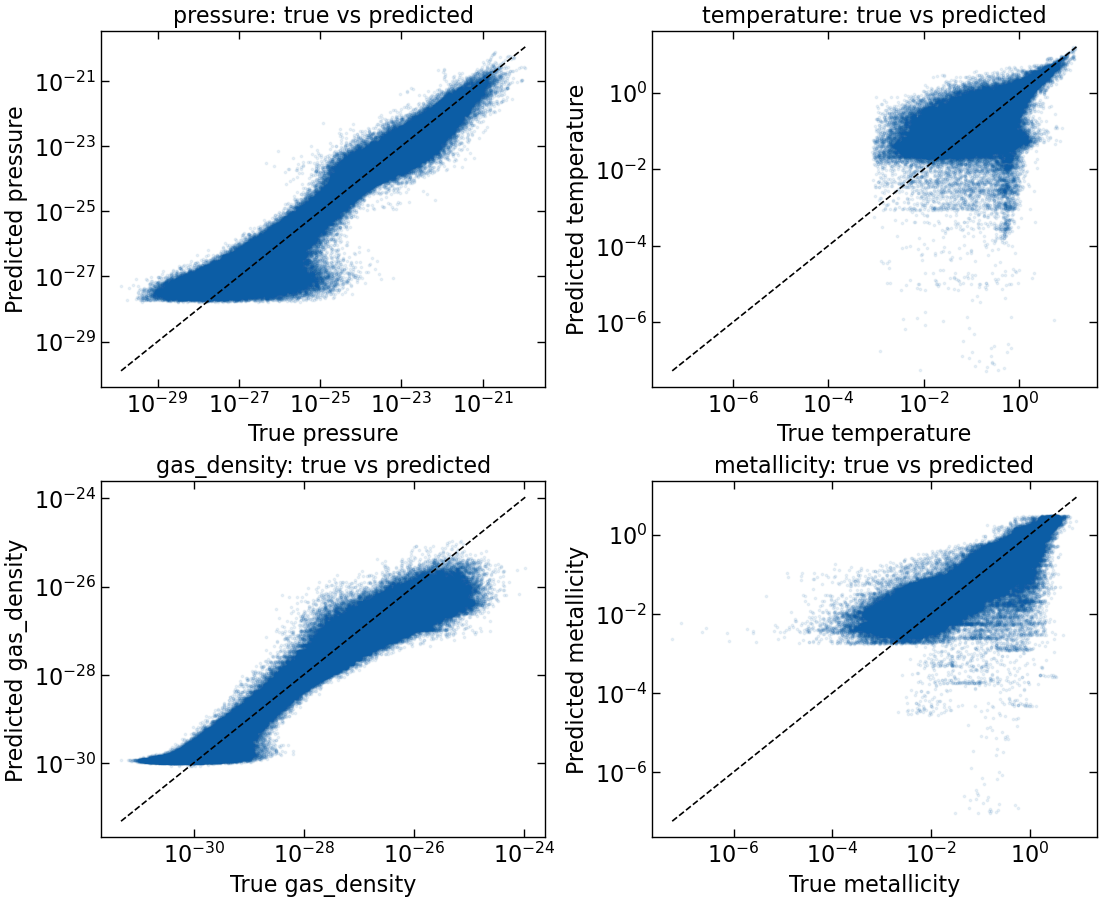

In [7]:
# Build test-set truth arrays, predict at matched (theta, mass, r/r500 bins), and summarize accuracy.
def load_run_arrays(run_id: int):
    fpath = resolve_profile_file(
        run_id,
        base_path=Path(args.profiles_base),
        suite=args.suite,
        sim_set=args.sim_set,
        snapnum=int(args.snapnum),
    )
    with np.load(fpath) as data:
        m500c = data['M500c'].astype(np.float32)
        r500c = data['R500c'].astype(np.float32)
        radial_bins = data['radial_bins'].astype(np.float32)
        pressure = data['pressure_array'].astype(np.float32)
        temperature = data['temperature_array'].astype(np.float32)
        gas_density = data['gas_density_array'].astype(np.float32)
        metallicity = data['metallicity_array'].astype(np.float32)

    return m500c, r500c, radial_bins, pressure, temperature, gas_density, metallicity


if 'run_id' in sb35_theta_df.columns:
    theta_source = sb35_theta_df.set_index('run_id')
else:
    theta_source = sb35_theta_df.copy()

target_fields = ['pressure', 'temperature', 'gas_density', 'metallicity']
available = set(emu.available_fields())

halo_rows = []
results = []
diag_rows = []
profile_cache = []
tiny = np.finfo(np.float64).tiny

for run_id in test_run_ids:
    # Load in the true data
    m500c, r500c, radial_bins, pressure, temperature, gas_density, metallicity = load_run_arrays(run_id)
    y_true = np.stack([pressure, temperature, gas_density, metallicity], axis=-1)
    y_true64 = y_true.astype(np.float64)

    radial_bins = np.asarray(radial_bins, dtype=np.float32).reshape(-1)
    if 'run_id' in sb35_theta_df.columns:
        theta = theta_source.loc[int(run_id)].to_numpy(dtype=np.float32)
    else:
        theta = theta_source.iloc[int(run_id)].to_numpy(dtype=np.float32)

    # We are using the R500s from the data so kind of cheating i guess...
    r_bins_rr500 = (
        radial_bins[None, :]
        / np.maximum(r500c.astype(np.float32)[:, None], np.float32(1e-8))
    ).astype(np.float32)
    pred = emu.predict(
        theta=theta,
        M=m500c.astype(np.float32),
        r_bins=r_bins_rr500,
        field=target_fields,
        n_samples=1,
    )
    y_pred = pred.mean.astype(np.float64)

    profile_cache.append({
        'run_id': int(run_id),
        'theta': theta.astype(np.float32).copy(),
        'm500c': m500c.astype(np.float32).copy(),
        'r500c': r500c.astype(np.float32).copy(),
        'rr500': r_bins_rr500.astype(np.float32).copy(),
        'radial_bins': radial_bins.astype(np.float32).copy(),
        'y_true': y_true64.copy(),
        'y_pred': y_pred.copy(),
        'field_names': list(target_fields),
    })

    for local_halo_idx, mass in enumerate(m500c):
        halo_rows.append(
            {
                'run_id': int(run_id),
                'local_halo_idx': int(local_halo_idx),
                'mass_m500c': float(mass),
                'log10_mass': float(np.log10(np.clip(mass, 1e10, None))),
            }
        )

    abs_err = np.abs(y_pred - y_true64)

    for j, field_name in enumerate(target_fields):
        yt = y_true64[:, :, j]
        yp = y_pred[:, :, j]
        ae = abs_err[:, :, j]
        pos_mask = (yt > 0.0) & (yp > 0.0)

        floor = max(float(np.nanpercentile(np.abs(yt), 1.0)), tiny)
        re = ae / np.maximum(np.abs(yt), floor)
        smape = 2.0 * ae / np.maximum(np.abs(yt) + np.abs(yp), floor)

        ss_res = float(np.sum((yp - yt) ** 2))
        yt_mu = float(np.mean(yt))
        ss_tot = float(np.sum((yt - yt_mu) ** 2))

        row = {
            'run_id': int(run_id),
            'field': str(field_name),
            'n_points': int(yt.size),
            'mae': float(np.mean(ae)),
            'rmse': float(np.sqrt(np.mean((yp - yt) ** 2))),
            'bias': float(np.mean(yp - yt)),
            'mape_clipped_pct': float(100.0 * np.mean(re)),
            'smape_pct': float(100.0 * np.mean(smape)),
            'median_ape_clipped_pct': float(100.0 * np.median(re)),
            'r2': float(1.0 - ss_res / ss_tot) if ss_tot > 0.0 else np.nan,
        }
        if np.any(pos_mask):
            dlog = np.log10(yp[pos_mask]) - np.log10(yt[pos_mask])
            row['log10_mae'] = float(np.mean(np.abs(dlog)))
            row['log10_rmse'] = float(np.sqrt(np.mean(dlog ** 2)))
        else:
            row['log10_mae'] = np.nan
            row['log10_rmse'] = np.nan

        results.append(row)

        diag_rows.append(
            pd.DataFrame({
                'field': str(field_name),
                'true': yt.ravel(),
                'pred': yp.ravel(),
            })
        )

halo_table = pd.DataFrame(halo_rows)
halo_table['mass_bin'] = pd.qcut(halo_table['log10_mass'], q=3, labels=['low', 'mid', 'high'])


diag = pd.concat(diag_rows, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(11.0, 9.0), constrained_layout=True)
axes = np.asarray(axes).ravel()

for ax, field_name in zip(axes, target_fields):
    d = diag[(diag['field'] == field_name) & (diag['true'] > 0.0) & (diag['pred'] > 0.0)]
    if d.empty:
        ax.text(0.5, 0.5, 'No positive points', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{field_name}: true vs predicted')
        continue

    ax.scatter(d['true'], d['pred'], s=3, alpha=0.08, rasterized=True)
    vmin = float(min(d['true'].min(), d['pred'].min()))
    vmax = float(max(d['true'].max(), d['pred'].max()))
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1.2)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(f'True {field_name}')
    ax.set_ylabel(f'Predicted {field_name}')
    ax.set_title(f'{field_name}: true vs predicted')

for ax in axes[len(target_fields):]:
    ax.set_visible(False)

plt.show()

## Single-Simulation Residuals (All Halos)

Pick one test simulation (`run_id`) and inspect profile residuals across all halos in that simulation. Residuals are computed in log-space as $\log_{10}(\mathrm{pred}) - \log_{10}(\mathrm{true})$.

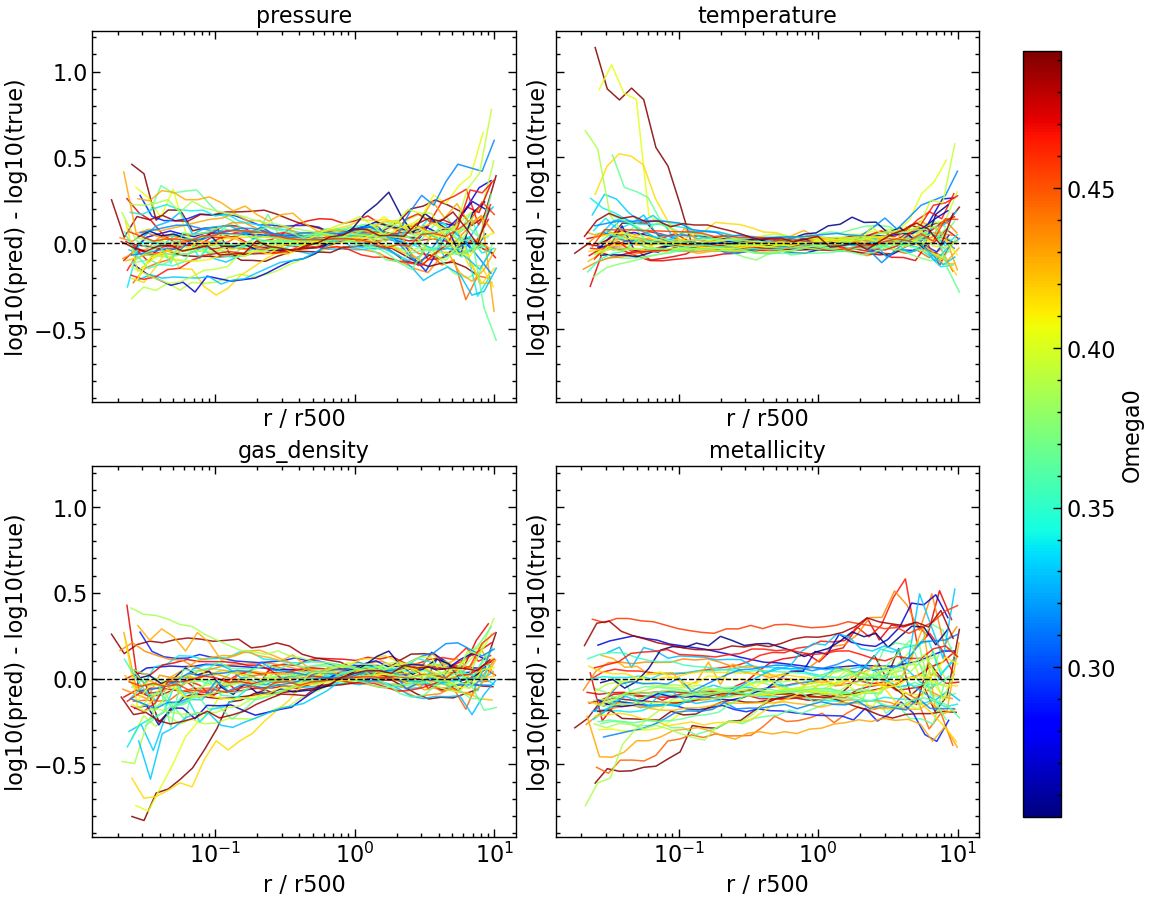

In [8]:
# Requires Cell 15 to be run first (builds profile_cache).
if 'profile_cache' not in globals() or len(profile_cache) == 0:
    raise RuntimeError('Run Cell 15 first so profile_cache is available.')

def median_residual_line(rr_in, yt_in, yp_in, n_bins=18):
    rr_flat = np.asarray(rr_in, dtype=np.float64).ravel()
    yt_flat = np.asarray(yt_in, dtype=np.float64).ravel()
    yp_flat = np.asarray(yp_in, dtype=np.float64).ravel()

    m = np.isfinite(rr_flat) & np.isfinite(yt_flat) & np.isfinite(yp_flat) & (rr_flat > 0) & (yt_flat > 0) & (yp_flat > 0)
    if np.count_nonzero(m) < 12:
        return np.array([]), np.array([])

    rr_u = rr_flat[m]
    dlog = np.log10(yp_flat[m]) - np.log10(yt_flat[m])

    lo = max(np.nanpercentile(rr_u, 1.0), 1e-4)
    hi = max(np.nanpercentile(rr_u, 99.0), lo * 1.1)
    edges = np.geomspace(lo, hi, n_bins + 1)
    centers = np.sqrt(edges[:-1] * edges[1:])

    bid = np.digitize(rr_u, edges) - 1
    med = np.full(n_bins, np.nan, dtype=np.float64)
    for k in range(n_bins):
        mk = bid == k
        if np.count_nonzero(mk) < 6:
            continue
        med[k] = np.nanmedian(dlog[mk])

    keep = np.isfinite(med)
    return centers[keep], med[keep]

def _resolve_param_column(theta_df, color_param):
    cols = list(theta_df.columns)
    q = str(color_param).strip().lower()
    if q == '':
        raise ValueError('color_param must be non-empty')

    exact = [c for c in cols if str(c).lower() == q]
    if exact:
        return exact[0]

    contains = [c for c in cols if q in str(c).lower()]
    if contains:
        return contains[0]

    raise KeyError(f"Parameter '{color_param}' not found in theta table columns")

def _build_mass_mask(m500c, mass_range=None, log10_mass_range=None):
    m500c = np.asarray(m500c, dtype=np.float64).reshape(-1)
    mask = np.isfinite(m500c) & (m500c > 0.0)

    if mass_range is not None:
        if len(mass_range) != 2:
            raise ValueError('mass_range must be a 2-tuple/list: (mmin, mmax)')
        mmin, mmax = [float(x) for x in mass_range]
        if not np.isfinite(mmin) or not np.isfinite(mmax) or mmin <= 0.0 or mmax <= mmin:
            raise ValueError('mass_range must satisfy: 0 < mmin < mmax')
        mask &= (m500c >= mmin) & (m500c <= mmax)

    if log10_mass_range is not None:
        if len(log10_mass_range) != 2:
            raise ValueError('log10_mass_range must be a 2-tuple/list: (log10_mmin, log10_mmax)')
        lmin, lmax = [float(x) for x in log10_mass_range]
        if not np.isfinite(lmin) or not np.isfinite(lmax) or lmax <= lmin:
            raise ValueError('log10_mass_range must satisfy: log10_mmin < log10_mmax')
        logm = np.log10(np.maximum(m500c, 1e-30))
        mask &= (logm >= lmin) & (logm <= lmax)

    return mask

def plot_multi_sim_residual_lines(color_param='Omega0', n_bins=31, cmap_name='viridis', mass_range=None, log10_mass_range=None, min_halos_per_run=1):
    if 'run_id' in sb35_theta_df.columns:
        theta_df = sb35_theta_df.set_index('run_id').copy()
    else:
        theta_df = sb35_theta_df.copy()
        theta_df.index = np.arange(len(theta_df), dtype=int)

    color_col = _resolve_param_column(theta_df, color_param)
    field_names = list(profile_cache[0]['field_names'])

    lines_by_field = {fname: [] for fname in field_names}
    for rec_i in profile_cache:
        run_i = int(rec_i['run_id'])
        if run_i not in theta_df.index:
            continue

        cval = float(theta_df.loc[run_i, color_col])
        halo_mask = _build_mass_mask(
            rec_i['m500c'],
            mass_range=mass_range,
            log10_mass_range=log10_mass_range,
        )
        if np.count_nonzero(halo_mask) < int(min_halos_per_run):
            continue

        rr_i = rec_i['rr500'][halo_mask, :].astype(np.float64)
        yt_i = rec_i['y_true'][halo_mask, :, :].astype(np.float64)
        yp_i = rec_i['y_pred'][halo_mask, :, :].astype(np.float64)

        for j, fname in enumerate(field_names):
            c_i, m_i = median_residual_line(rr_i, yt_i[:, :, j], yp_i[:, :, j], n_bins=n_bins)
            if c_i.size == 0:
                continue
            lines_by_field[fname].append((cval, c_i, m_i))

    all_c = [x[0] for fname in field_names for x in lines_by_field[fname]]
    if len(all_c) == 0:
        raise RuntimeError('No valid multi-run residual lines could be computed for any field after mass filtering.')

    cvals = np.array(all_c, dtype=np.float64)
    norm = plt.Normalize(vmin=float(np.nanmin(cvals)), vmax=float(np.nanmax(cvals)))
    cmap = plt.get_cmap(cmap_name)

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.0), constrained_layout=True, sharex=True, sharey=True)
    axes = np.asarray(axes).ravel()

    for ax, fname in zip(axes, field_names):
        for cval, c_i, m_i in lines_by_field[fname]:
            ax.plot(c_i, m_i, color=cmap(norm(cval)), alpha=0.85, lw=1.1)
        ax.axhline(0.0, color='k', ls='--', lw=1.0)
        ax.set_xscale('log')
        ax.set_xlabel('r / r500')
        ax.set_ylabel('log10(pred) - log10(true)')
        ax.set_title(f'{fname}')

    for ax in axes[len(field_names):]:
        ax.set_visible(False)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes.tolist(), shrink=0.95)
    cbar.set_label(str(color_col))
    plt.show()

plot_multi_sim_residual_lines(color_param='Omega0', n_bins=31, 
                              cmap_name='jet', log10_mass_range=(13.5, 16))

## One-Parameter Sensitivity for a Single Test Halo

For one representative halo from the test set, vary one parameter at a time to the prior low/high bounds and compare to the fiducial prediction.

- Fiducial, low, high: read from `SB35_param_minmax.csv`.
- Radius grid: reconstructed from the training recipe (`rmin=10`, `rmax=5000`, `nbins=30`).
- Each panel shows pressure ratio `modulated / fiducial` vs radius in kpc with two curves (prior low and prior high).
- Shaded bands show propagated 1-sigma uncertainty for each ratio using
  `sigma_ratio ~ ratio * sqrt((sigma_mod/mu_mod)^2 + (sigma_fid/mu_fid)^2)`.

In [9]:
# TARGET_LOG10_M = 13
# PRIOR_CSV = Path('/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv')

# # Requested mass bins: 10^12, 10^12.5, 10^13, 10^13.5 (Msun-like units used in training).
# LOG10_MASS_BINS = np.array([12.0, 13.0, 16], dtype=np.float32)
# MASS_BINS = np.power(10.0, LOG10_MASS_BINS).astype(np.float32)

# # Reconstruct the training radial-bin centers in kpc.
# rmin = 10.0
# rmax = 2000.0
# nbins = 51
# dx = np.log10(rmax / rmin) / nbins
# log_radial_bins = np.array([np.log10(rmin) + (float(i) + 0.5) * dx for i in range(nbins)], dtype=np.float32)
# radial_bins_kpc = np.logspace(-2, np.log10(10), nbins)#np.power(10.0, log_radial_bins).astype(np.float32)


# # Load prior min/max/fiducial values.
# prior_df = pd.read_csv(PRIOR_CSV)
# prior_df = prior_df.set_index('ParamName')

# param_names = list(theta_df.columns)
# missing = [p for p in param_names if p not in prior_df.index]
# if missing:
#     raise KeyError(f'Missing parameters in prior file: {missing}')

# param_low = prior_df.loc[param_names, 'MinVal'].to_numpy(dtype=np.float32)
# param_high = prior_df.loc[param_names, 'MaxVal'].to_numpy(dtype=np.float32)
# theta_fid = prior_df.loc[param_names, 'FiducialVal'].to_numpy(dtype=np.float32)

# 1P tests

In [10]:
# Per-suffix 1P generation: each parameter tag uses its own halo catalog.

import re
from pathlib import Path

ONEP_PARAM_FILE = Path('/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/1P/CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt')
ONEP_PROFILE_DIR = Path('Profiles_cy')
ONEP_SNAPNUM = 90

N_SAMPLES_1P = 50
REQUESTED_FIELDS = ['pressure', 'temperature', 'gas_density', 'metallicity']

if not ONEP_PARAM_FILE.exists():
    raise FileNotFoundError(f'Parameter file not found: {ONEP_PARAM_FILE}')
if not ONEP_PROFILE_DIR.exists():
    raise FileNotFoundError(f'Profile directory not found: {ONEP_PROFILE_DIR}')

# 1) Load the 1P parameter table and normalize tag column name.
onep_params = pd.read_csv(ONEP_PARAM_FILE, sep=r'\s+', engine='python')
if '#Name' in onep_params.columns:
    onep_params = onep_params.rename(columns={'#Name': 'tag'})
if 'tag' not in onep_params.columns:
    raise KeyError("Expected '#Name' (or 'tag') column in ONEP_PARAM_FILE")

# 2) Build tag -> profile path map from Profiles_cy files.
tag_to_profile = {}
pat = re.compile(r'IllustrisTNG_(.+)_snap(\d+)\.npz$')
for fp in sorted(ONEP_PROFILE_DIR.glob('IllustrisTNG_1P_*_snap*.npz')):
    m = pat.match(fp.name)
    if m is None:
        continue
    tag = m.group(1)
    snap = int(m.group(2))
    if snap == int(ONEP_SNAPNUM):
        tag_to_profile[tag] = fp

# 3) Choose theta columns for the emulator (exclude non-parameter columns like tag/seed).
if 'theta_cols_ref' in globals() and isinstance(theta_cols_ref, list):
    theta_cols = [c for c in theta_cols_ref if c in onep_params.columns][: emu.theta_dim]
else:
    theta_cols = []

if len(theta_cols) != emu.theta_dim:
    numeric_cols = [
        c for c in onep_params.columns
        if c != 'tag' and pd.api.types.is_numeric_dtype(onep_params[c])
    ]
    numeric_cols = [c for c in numeric_cols if c.lower() != 'seed']
    if len(numeric_cols) < emu.theta_dim:
        raise ValueError(
            f'Need at least {emu.theta_dim} numeric parameter columns, found {len(numeric_cols)}'
        )
    theta_cols = numeric_cols[: emu.theta_dim]

# 4) Generate predictions for all halos in each available tag, and load true profiles.
onep_predictions = {}
summary_rows = []
missing_profile_tags = []

for _, row in onep_params.iterrows():
    tag = str(row['tag'])
    fpath = tag_to_profile.get(tag)
    if fpath is None:
        missing_profile_tags.append(tag)
        continue

    theta_tag = row[theta_cols].to_numpy(dtype=np.float32)
    with np.load(fpath) as dat:
        masses = dat['M500c'].astype(np.float32)
        radial_bins = dat['radial_bins'].astype(np.float32)
        r500c = dat['R500c'].astype(np.float32) if 'R500c' in dat else None

        true_profiles = {}
        for fld in REQUESTED_FIELDS:
            key = f'{fld}_array'
            if key not in dat:
                raise KeyError(f'Missing true profile array {key} in {fpath}')
            true_profiles[fld] = dat[key].astype(np.float32)

    # Emulator expects r/R500. Build per-halo radius grids in one vectorized array.
    if r500c is None:
        raise ValueError(f'Missing R500c in {fpath}; cannot construct per-halo r/R500 bins')
    r_bins_rr500 = (
        radial_bins[None, :]
        / np.maximum(r500c[:, None], np.float32(1e-12))
    ).astype(np.float32)

    pred = emu.predict(
        theta=theta_tag,
        M=masses,
        r_bins=r_bins_rr500,
        field=REQUESTED_FIELDS,
        n_samples=N_SAMPLES_1P,
    )

    onep_predictions[tag] = {
        'profile_path': str(fpath),
        'theta': theta_tag,
        'M500c': masses,
        'R500c': r500c,
        'rr500': r_bins_rr500,
        'radial_bins': radial_bins,
        'true_profiles': true_profiles,
        'pred': pred,
    }

    summary_rows.append(
        {
            'tag': tag,
            'profile_file': fpath.name,
            'n_halos': int(masses.shape[0]),
            'n_r': int(radial_bins.shape[0]),
            'fields': ','.join(pred.field_names),
            'mean_shape': tuple(pred.mean.shape),
            'true_pressure_shape': tuple(true_profiles['pressure'].shape),
        }
    )

onep_summary_df = pd.DataFrame(summary_rows).sort_values('tag').reset_index(drop=True)

print(f'Loaded parameter rows: {len(onep_params)}')
print(f'Matched profile files @ snap {ONEP_SNAPNUM}: {len(tag_to_profile)}')
print(f'Generated predictions for tags: {len(onep_predictions)}')
print(f'Missing profile tags: {len(missing_profile_tags)}')

if missing_profile_tags:
    print('First missing tags:', missing_profile_tags[:10])

display(onep_summary_df.head(10))

# Example access for one tag:
example_tag = onep_summary_df.loc[0, 'tag'] if len(onep_summary_df) > 0 else None
if example_tag is not None:
    example = onep_predictions[example_tag]
    print(f"Example tag: {example_tag}")
    print('pred.mean shape:', example['pred'].mean.shape)
    print('pred.total_std shape:', example['pred'].total_std.shape)
    print('true pressure shape:', example['true_profiles']['pressure'].shape)

Loaded parameter rows: 141
Matched profile files @ snap 90: 160
Generated predictions for tags: 129
Missing profile tags: 12
First missing tags: ['1P_p29_n1', '1P_p29_1', '1P_p29_2', '1P_p29_3', '1P_p30_n4', '1P_p30_n3', '1P_p30_n2', '1P_p30_n1', '1P_p32_n4', '1P_p32_n3']


,tag,profile_file,n_halos,n_r,fields,mean_shape,true_pressure_shape
0,1P_p10_1,IllustrisTNG_1P_p10_1_snap090.npz,124,30,"pressure,temperature,gas_density,metallicity","(124, 30, 4)","(124, 30)"
1,1P_p10_2,IllustrisTNG_1P_p10_2_snap090.npz,126,30,"pressure,temperature,gas_density,metallicity","(126, 30, 4)","(126, 30)"
2,1P_p10_n1,IllustrisTNG_1P_p10_n1_snap090.npz,124,30,"pressure,temperature,gas_density,metallicity","(124, 30, 4)","(124, 30)"
3,1P_p10_n2,IllustrisTNG_1P_p10_n2_snap090.npz,122,30,"pressure,temperature,gas_density,metallicity","(122, 30, 4)","(122, 30)"
4,1P_p11_1,IllustrisTNG_1P_p11_1_snap090.npz,124,30,"pressure,temperature,gas_density,metallicity","(124, 30, 4)","(124, 30)"
5,1P_p11_2,IllustrisTNG_1P_p11_2_snap090.npz,127,30,"pressure,temperature,gas_density,metallicity","(127, 30, 4)","(127, 30)"
6,1P_p11_n1,IllustrisTNG_1P_p11_n1_snap090.npz,124,30,"pressure,temperature,gas_density,metallicity","(124, 30, 4)","(124, 30)"
7,1P_p11_n2,IllustrisTNG_1P_p11_n2_snap090.npz,123,30,"pressure,temperature,gas_density,metallicity","(123, 30, 4)","(123, 30)"
8,1P_p12_1,IllustrisTNG_1P_p12_1_snap090.npz,122,30,"pressure,temperature,gas_density,metallicity","(122, 30, 4)","(122, 30)"
9,1P_p12_2,IllustrisTNG_1P_p12_2_snap090.npz,119,30,"pressure,temperature,gas_density,metallicity","(119, 30, 4)","(119, 30)"


Example tag: 1P_p10_1
pred.mean shape: (124, 30, 4)
pred.total_std shape: (124, 30, 4)
true pressure shape: (124, 30)


Tag: 1P_p10_1 | field: pressure
Total halos: 124
Low-mass halos (< 1.00e+13): 95
High-mass halos (>= 1.00e+13): 29
Array shapes:
  true_low : (95, 30) pred_low : (95, 30)
  true_high: (29, 30) pred_high: (29, 30)


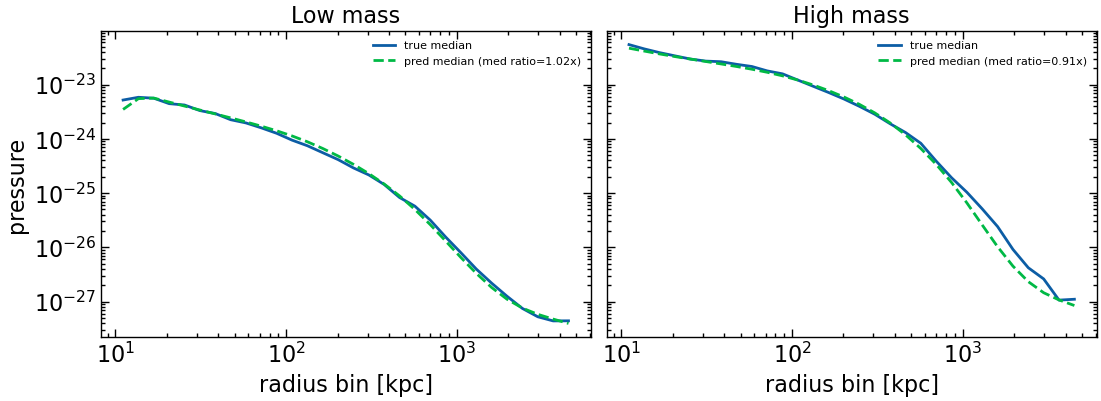

In [11]:
# Split halos by mass and compare true vs predicted profiles for one 1P tag.
# Uses cached predictions from Cell 21 (no re-prediction).

TAG = '1P_p10_1'
FIELD = 'pressure'
MASS_CUT = 1e13

if TAG not in onep_predictions:
    raise KeyError(f'Tag {TAG} not found. Available tags example: {list(onep_predictions)[:5]}')

entry = onep_predictions[TAG]
m_tag = np.asarray(entry['M500c'], dtype=np.float64)
r_tag = np.asarray(entry['radial_bins'], dtype=np.float64)
true_field = np.asarray(entry['true_profiles'][FIELD], dtype=np.float64)

pred_obj = entry.get('pred', None)
if pred_obj is None:
    raise ValueError(f"No cached prediction found for tag '{TAG}'. Re-run Cell 21.")

pred_mean = np.asarray(pred_obj.mean, dtype=np.float64)
field_names = list(pred_obj.field_names)
if FIELD not in field_names:
    raise KeyError(f"Field '{FIELD}' not in cached prediction fields: {field_names}")
field_idx = field_names.index(FIELD)

if pred_mean.ndim == 3:
    pred_scaled = pred_mean[:, :, field_idx]
elif pred_mean.ndim == 2 and len(field_names) == 1 and field_names[0] == FIELD:
    pred_scaled = pred_mean
else:
    raise ValueError(f'Unexpected cached pred.mean shape for {FIELD}: {pred_mean.shape}')

if true_field.shape != pred_scaled.shape:
    raise ValueError(f'Shape mismatch for {FIELD}: true={true_field.shape}, pred={pred_scaled.shape}')
if true_field.shape[0] != m_tag.shape[0]:
    raise ValueError('Mass array length does not match number of halos in profile arrays')

low_mask = m_tag < MASS_CUT
high_mask = ~low_mask

true_low = true_field[low_mask]
true_high = true_field[high_mask]
pred_low = pred_scaled[low_mask]
pred_high = pred_scaled[high_mask]

print(f'Tag: {TAG} | field: {FIELD}')
print(f'Total halos: {m_tag.size}')
print(f'Low-mass halos (< {MASS_CUT:.2e}): {low_mask.sum()}')
print(f'High-mass halos (>= {MASS_CUT:.2e}): {high_mask.sum()}')
print('Array shapes:')
print('  true_low :', true_low.shape, 'pred_low :', pred_low.shape)
print('  true_high:', true_high.shape, 'pred_high:', pred_high.shape)

# Plot median profile for true and predicted in low/high mass bins.
eps_plot = 1e-30
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, constrained_layout=True)

for ax, label, t_arr, p_arr in [
    (axes[0], 'Low mass', true_low, pred_low),
    (axes[1], 'High mass', true_high, pred_high),
]:
    if t_arr.shape[0] == 0:
        ax.text(0.5, 0.5, 'No halos in bin', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label)
        ax.set_xscale('log')
        continue

    t_med = np.median(np.clip(t_arr, eps_plot, None), axis=0)
    p_med = np.median(np.clip(p_arr, eps_plot, None), axis=0)
    ratio = np.median(p_med / np.clip(t_med, eps_plot, None))
    ax.plot(r_tag, t_med, lw=2, label='true median')
    ax.plot(r_tag, p_med, lw=2, ls='--', label=f'pred median (med ratio={ratio:.2f}x)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(label)
    ax.set_xlabel('radius bin [kpc]')
    ax.legend(fontsize=8)

axes[0].set_ylabel(FIELD)
plt.show()

In [12]:
# Reusable family plot for one 1P parameter with dynamic suffix discovery.

def plot_onep_family(
    base_param: str,
    field: str = 'pressure',
    mass_cut: float = 1e13,
    n_samples_compare: int = 25,
    fiducial_tag: str = '1P_p1_0',
):
    """Plot true (mean +- SEM) and cached model predictions for a 1P family.

    Notes
    -----
    - This version does not re-run the emulator. It uses cached predictions from Cell 21.
    - If a tag has truth data but no cached prediction, that panel is shown as "true only".
    """

    _ = (n_samples_compare, fiducial_tag)  # kept for backward-compatible function signature

    import re

    def _load_profile_arrays(tag: str, field_name: str):
        if tag in onep_predictions:
            entry = onep_predictions[tag]
            m_tag = np.asarray(entry['M500c'], dtype=np.float64)
            r_tag = np.asarray(entry['radial_bins'], dtype=np.float64)
            true_field = np.asarray(entry['true_profiles'][field_name], dtype=np.float64)
            pred_obj = entry.get('pred', None)
            return m_tag, r_tag, true_field, pred_obj

        fpath = tag_to_profile.get(tag, None)
        if fpath is None:
            return None

        with np.load(fpath) as dat:
            key = f'{field_name}_array'
            if key not in dat:
                return None
            m_tag = np.asarray(dat['M500c'], dtype=np.float64)
            r_tag = np.asarray(dat['radial_bins'], dtype=np.float64)
            true_field = np.asarray(dat[key], dtype=np.float64)
        return m_tag, r_tag, true_field, None

    def _extract_field_from_cached_pred(pred_obj, field_name: str):
        if pred_obj is None:
            return None, None

        field_names = list(pred_obj.field_names)
        if field_name not in field_names:
            return None, None
        idx = field_names.index(field_name)

        mu_all = np.asarray(pred_obj.mean, dtype=np.float64)
        sd_all = np.asarray(pred_obj.total_std, dtype=np.float64)

        if mu_all.ndim == 3:
            mu = mu_all[:, :, idx]
            sd = sd_all[:, :, idx]
        elif mu_all.ndim == 2 and len(field_names) == 1 and field_names[0] == field_name:
            mu = mu_all
            sd = sd_all
        else:
            return None, None

        return mu, sd

    def _suffix_numeric_value(sfx: str):
        if sfx == '0':
            return 0
        m_neg = re.fullmatch(r'n(\d+)', sfx)
        if m_neg is not None:
            return -int(m_neg.group(1))
        if re.fullmatch(r'\d+', sfx):
            return int(sfx)
        return None

    def _discover_suffixes(base: str):
        prefix = f'1P_{base}_'
        tag_pool = set()

        if 'onep_predictions' in globals() and isinstance(onep_predictions, dict):
            tag_pool.update([str(k) for k in onep_predictions.keys()])
        if 'tag_to_profile' in globals() and isinstance(tag_to_profile, dict):
            tag_pool.update([str(k) for k in tag_to_profile.keys()])
        if 'onep_params' in globals() and isinstance(onep_params, pd.DataFrame) and 'tag' in onep_params.columns:
            tag_pool.update(onep_params['tag'].astype(str).tolist())

        suffixes = []
        for t in tag_pool:
            if t.startswith(prefix):
                suffixes.append(t[len(prefix):])

        suffixes = list(dict.fromkeys(suffixes))
        if '0' not in suffixes:
            suffixes.append('0')

        numeric_suffixes = [s for s in suffixes if _suffix_numeric_value(s) is not None]
        other_suffixes = [s for s in suffixes if _suffix_numeric_value(s) is None]

        def _suffix_sort_key(s: str):
            v = _suffix_numeric_value(s)
            return 0 if v is None else int(v)

        numeric_suffixes = sorted(numeric_suffixes, key=_suffix_sort_key)
        other_suffixes = sorted(other_suffixes)

        ordered = numeric_suffixes + other_suffixes
        if len(ordered) == 0:
            ordered = ['0']
        return ordered

    def _compute_split_stats_for_tag(tag: str):
        loaded = _load_profile_arrays(tag, field)
        if loaded is None:
            return None

        m_tag, r_tag, true_field, pred_obj = loaded
        low_mask = m_tag < mass_cut
        high_mask = ~low_mask
        eps_plot = 1e-30
        ln10 = np.log(10.0)

        out = {
            'tag': tag,
            'r_kpc': r_tag,
            'n_low': int(low_mask.sum()),
            'n_high': int(high_mask.sum()),
            'has_pred': False,
            'theta_source': None,
            'true_low_c': None,
            'true_low_e': None,
            'true_high_c': None,
            'true_high_e': None,
            'pred_low_c': None,
            'pred_low_lo': None,
            'pred_low_hi': None,
            'pred_high_c': None,
            'pred_high_lo': None,
            'pred_high_hi': None,
            'ratio_low': np.nan,
            'ratio_high': np.nan,
        }

        def _true_center_err(arr):
            if arr.shape[0] == 0:
                return None, None
            clipped = np.clip(arr, eps_plot, None)
            center = np.mean(clipped, axis=0)
            n = clipped.shape[0]
            if n > 1:
                err = np.std(clipped, axis=0, ddof=1) / np.sqrt(float(n))
            else:
                err = np.zeros(clipped.shape[1], dtype=np.float64)
            return center, err

        true_low = true_field[low_mask]
        true_high = true_field[high_mask]
        out['true_low_c'], out['true_low_e'] = _true_center_err(true_low)
        out['true_high_c'], out['true_high_e'] = _true_center_err(true_high)

        pred_mu_all, pred_sd_all = _extract_field_from_cached_pred(pred_obj, field)
        if pred_mu_all is None or pred_sd_all is None:
            return out

        if pred_mu_all.shape != true_field.shape:
            return out

        def _pred_center_band(mu_arr, sd_arr):
            if mu_arr.shape[0] == 0:
                return None, None, None
            mu_clip = np.clip(mu_arr, eps_plot, None)
            sd_clip = np.clip(sd_arr, 0.0, None)
            n = mu_clip.shape[0]

            c = np.mean(mu_clip, axis=0)

            if n > 1:
                sem_halo = np.std(mu_clip, axis=0, ddof=1) / np.sqrt(float(n))
            else:
                sem_halo = np.zeros(mu_clip.shape[1], dtype=np.float64)
            sem_pred = np.sqrt(np.mean(sd_clip ** 2, axis=0) / float(n))
            sem_total = np.sqrt(sem_halo ** 2 + sem_pred ** 2)

            sigma_log = sem_total / np.maximum(ln10 * np.clip(c, eps_plot, None), eps_plot)
            lo = c * np.power(10.0, -sigma_log)
            hi = c * np.power(10.0, sigma_log)
            lo = np.clip(lo, eps_plot, None)
            hi = np.clip(hi, eps_plot, None)
            return c, lo, hi

        pred_low_mu = pred_mu_all[low_mask]
        pred_low_sd = pred_sd_all[low_mask]
        pred_high_mu = pred_mu_all[high_mask]
        pred_high_sd = pred_sd_all[high_mask]

        out['pred_low_c'], out['pred_low_lo'], out['pred_low_hi'] = _pred_center_band(pred_low_mu, pred_low_sd)
        out['pred_high_c'], out['pred_high_lo'], out['pred_high_hi'] = _pred_center_band(pred_high_mu, pred_high_sd)

        if out['pred_low_c'] is not None and out['true_low_c'] is not None:
            out['ratio_low'] = float(np.median(out['pred_low_c'] / np.clip(out['true_low_c'], eps_plot, None)))
        if out['pred_high_c'] is not None and out['true_high_c'] is not None:
            out['ratio_high'] = float(np.median(out['pred_high_c'] / np.clip(out['true_high_c'], eps_plot, None)))

        out['has_pred'] = True
        out['theta_source'] = tag
        return out

    suffixes = _discover_suffixes(base_param)
    tags = [f'1P_{base_param}_{s}' for s in suffixes]

    n_panels = len(tags)
    fig_w = max(10.0, 4.2 * n_panels)
    fig, axes = plt.subplots(1, n_panels, figsize=(fig_w, 4), sharey=True, constrained_layout=True)
    if n_panels == 1:
        axes = [axes]

    for ax, tag in zip(axes, tags):
        res = _compute_split_stats_for_tag(tag)
        if res is None:
            ax.text(0.5, 0.5, f'{tag}\nmissing profile', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(tag)
            ax.set_xscale('log')
            continue

        r_kpc = res['r_kpc']

        if res['true_low_c'] is not None:
            ax.errorbar(
                r_kpc, res['true_low_c'], yerr=res['true_low_e'],
                fmt='o', ms=2.5, lw=0.8, elinewidth=0.7, capsize=1.8,
                color='tab:blue', alpha=0.9,
            )
        if res['true_high_c'] is not None:
            ax.errorbar(
                r_kpc, res['true_high_c'], yerr=res['true_high_e'],
                fmt='o', ms=2.5, lw=0.8, elinewidth=0.7, capsize=1.8,
                color='tab:orange', alpha=0.9,
            )

        if res['pred_low_c'] is not None:
            ax.plot(r_kpc, res['pred_low_c'], color='tab:blue', lw=1.8, ls='-')
            ax.fill_between(r_kpc, res['pred_low_lo'], res['pred_low_hi'], color='tab:blue', alpha=0.18, linewidth=0)
        if res['pred_high_c'] is not None:
            ax.plot(r_kpc, res['pred_high_c'], color='tab:orange', lw=1.8, ls='-')
            ax.fill_between(r_kpc, res['pred_high_lo'], res['pred_high_hi'], color='tab:orange', alpha=0.18, linewidth=0)

        ax.set_xscale('log')
        ax.set_yscale('log')
        if res['has_pred']:
            subtitle = f"low={res['ratio_low']:.2f}x, high={res['ratio_high']:.2f}x"
        else:
            subtitle = 'true only'
        ax.set_title(f'{tag}\n{subtitle}', fontsize=9)
        ax.set_xlabel('radius [kpc]')

    axes[0].set_ylabel(field)

    legend_handles = [
        plt.Line2D([0], [0], color='tab:blue', marker='o', linestyle='None', markersize=4, label='true low (mean +- SEM)'),
        plt.Line2D([0], [0], color='tab:orange', marker='o', linestyle='None', markersize=4, label='true high (mean +- SEM)'),
        plt.Line2D([0], [0], color='tab:blue', lw=2.0, label='model low (mean line)'),
        plt.Line2D([0], [0], color='tab:orange', lw=2.0, label='model high (mean line)'),
        plt.Rectangle((0, 0), 1, 1, fc='gray', alpha=0.18, label='model mean uncertainty band (log-space)'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.08))
    fig.suptitle(f"{base_param} family: {', '.join(suffixes)}", y=1.14)
    plt.show()

In [13]:
def plot_onep_family_grid(
    base_params=None, field='pressure', mass_cut=1e13, n_samples_compare=10,
    fiducial_tag='1P_p1_0', variation_suffixes=None, max_rows=None,
    row_height=2.6, col_width=3.8, n_cols=5,
    param_csv=Path('/mnt/home/mlee1/50Mpc_boxes/data/param_df.csv'),
):
    import re

    _ = (n_samples_compare,)  # kept for backward-compatible function signature

    variation_suffixes = [str(s) for s in (variation_suffixes or ['n2', 'n1', '1', '2'])]
    assert len(variation_suffixes) == 4, 'Need exactly 4 variation suffixes'

    # --- Parameter name helpers ---
    try:
        param_name_map = {f'p{i+1}': c for i, c in enumerate(pd.read_csv(param_csv, nrows=0).columns)}
    except Exception:
        param_name_map = {}

    MANUAL_LATEX = {'Omega0': r'$\Omega_0$', 'OmegaBaryon': r'$\Omega_b$',
                    'sigma8': r'$\sigma_8$', 'n_s': '$n_s$', 'HubbleParam': '$h$'}

    def pretty_param(base):
        name = param_name_map.get(base, base)
        if name in MANUAL_LATEX:
            return MANUAL_LATEX[name]
        if match := re.fullmatch(r'sigma(\d+)', name):
            return rf'$\sigma_{{{match.group(1)}}}$'
        return name

    # --- Data loading from cached 1P predictions ---
    def load_cached(tag):
        if tag not in onep_predictions:
            return None
        e = onep_predictions[tag]
        if field not in e['true_profiles']:
            return None

        pred_obj = e.get('pred', None)
        if pred_obj is None:
            return None

        field_names = list(pred_obj.field_names)
        if field not in field_names:
            return None
        j = field_names.index(field)

        true_field = np.asarray(e['true_profiles'][field], dtype=np.float64)
        masses = np.asarray(e['M500c'], dtype=np.float64)
        r_kpc = np.asarray(e['radial_bins'], dtype=np.float64)

        mu_all = np.asarray(pred_obj.mean, dtype=np.float64)
        if hasattr(pred_obj, 'epistemic_std'):
            sd_all = np.asarray(pred_obj.epistemic_std, dtype=np.float64)
        else:
            sd_all = np.asarray(pred_obj.total_std, dtype=np.float64)

        if mu_all.ndim == 3:
            pred_mu = mu_all[:, :, j]
            pred_sd = sd_all[:, :, j]
        elif mu_all.ndim == 2 and len(field_names) == 1 and field_names[0] == field:
            pred_mu = mu_all
            pred_sd = sd_all
        else:
            return None

        if not (true_field.shape == pred_mu.shape == pred_sd.shape):
            return None

        return masses, r_kpc, true_field, pred_mu, np.clip(pred_sd, 0.0, None)

    # --- Core stats computation (no emulator calls) ---
    EPS, LN10 = 1e-30, np.log(10.0)

    def compute_stats(tag):
        cached = load_cached(tag)
        if cached is None:
            return None
        m, r_kpc, true_field, pred_mu, pred_sd = cached

        def split(mask):
            if not np.any(mask):
                return None, None, None, None
            n = int(mask.sum())
            t = true_field[mask]
            mu = pred_mu[mask]
            sd = pred_sd[mask]

            tc = t.mean(0)
            tsem = t.std(0, ddof=1) / n**0.5 if n > 1 else np.zeros(t.shape[1])

            pc = mu.mean(0)
            sem_halo = mu.std(0, ddof=1) / n**0.5 if n > 1 else np.zeros(mu.shape[1])
            sem_pred = np.sqrt(np.mean(sd**2, 0)) / n**0.5
            sem_total = np.sqrt(sem_halo**2 + sem_pred**2)
            sigma_log = np.clip(sem_total / np.maximum(LN10 * np.abs(pc), EPS), 0, 0.3)

            return tc, tsem, pc, sigma_log

        return {'r_kpc': r_kpc, 'stats': split(m >= mass_cut)}

    # --- Discover base params ---
    if base_params is None:
        pat = re.compile(r'^1P_(.+)_.+$')
        pool = (
            list(onep_predictions)
            + list(tag_to_profile)
            + (onep_params['tag'].tolist() if 'onep_params' in globals() else [])
        )
        base_params = sorted(
            {match.group(1) for t in pool if (match := pat.match(str(t)))},
            key=lambda x: (0, int(x[1:])) if re.fullmatch(r'p\d+', x) else (1, x),
        )
    base_params = [str(b) for b in base_params][:max_rows]

    # --- Layout ---
    n_params = len(base_params)
    n_rows = int(np.ceil(n_params / n_cols))
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(col_width * n_cols, row_height * n_rows),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    COLORS = plt.cm.seismic(np.linspace(0, 1, 4))
    cache = {}

    for pidx, base in enumerate(base_params):
        ax = axes[pidx // n_cols, pidx % n_cols]
        ax.set_xscale('log')
        ax.set_title(pretty_param(base), fontsize=8)
        if pidx % n_cols == 0:
            ax.set_ylabel('variation / fiducial', fontsize=8)
        if pidx // n_cols == n_rows - 1:
            ax.set_xlabel('radius [kpc]', fontsize=8)
        ax.tick_params(labelsize=7)

        # Prefer parameter-specific fiducial if present, else fall back to shared fiducial_tag.
        fid_tag_local = f'1P_{base}_0'
        cache.setdefault(fid_tag_local, compute_stats(fid_tag_local))
        fid = cache[fid_tag_local]
        fid_source_tag = fid_tag_local

        if fid is None or fid['stats'][2] is None:
            cache.setdefault(fiducial_tag, compute_stats(fiducial_tag))
            fid = cache[fiducial_tag]
            fid_source_tag = fiducial_tag

        if fid is None or fid['stats'][2] is None:
            ax.text(
                0.5,
                0.5,
                f'{pretty_param(base)}\nmissing fiducial ({fiducial_tag})',
                ha='center',
                va='center',
                transform=ax.transAxes,
                fontsize=7,
            )
            continue

        r_kpc = fid['r_kpc']
        ftc, ftsem, fpc, fsl = fid['stats']

        for sfx, color in zip(variation_suffixes, COLORS):
            tag = f'1P_{base}_{sfx}'
            cache.setdefault(tag, compute_stats(tag))
            if (res := cache[tag]) is None:
                continue
            tc, tsem, pc, sl = res['stats']

            # --- model ratio + propagated epistemic contour ---
            if pc is not None:
                ratio = pc / np.where(np.abs(fpc) > EPS, fpc, np.nan)
                ax.plot(r_kpc, ratio, color=color, ls='-', lw=1.2)

            # --- true ratio + propagated SEM error bars ---
            if tc is not None:
                denom = np.where(np.abs(ftc) > EPS, ftc, np.nan)
                ratio_t = tc / denom
                frac_v = np.clip(np.abs(tsem / np.where(np.abs(tc) > EPS, tc, np.nan)), 0, 0.5)
                frac_f = np.clip(np.abs(ftsem / np.where(np.abs(ftc) > EPS, ftc, np.nan)), 0, 0.5)
                err = np.abs(ratio_t) * np.sqrt(frac_v**2 + frac_f**2)
                idx = np.arange(0, ratio_t.size, max(1, ratio_t.size // 12))
                ax.errorbar(
                    r_kpc[idx],
                    ratio_t[idx],
                    yerr=err[idx],
                    fmt='o',
                    ms=2,
                    lw=0.6,
                    elinewidth=0.6,
                    capsize=1.5,
                    color=color,
                    alpha=0.5,
                )

        ax.axhline(1.0, color='k', lw=0.8, alpha=0.55)
        if fid_source_tag != fid_tag_local:
            ax.text(0.03, 0.96, f'fid: {fid_source_tag}', transform=ax.transAxes, va='top', ha='left', fontsize=6)

    for k in range(n_params, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].set_visible(False)

    plt.show()

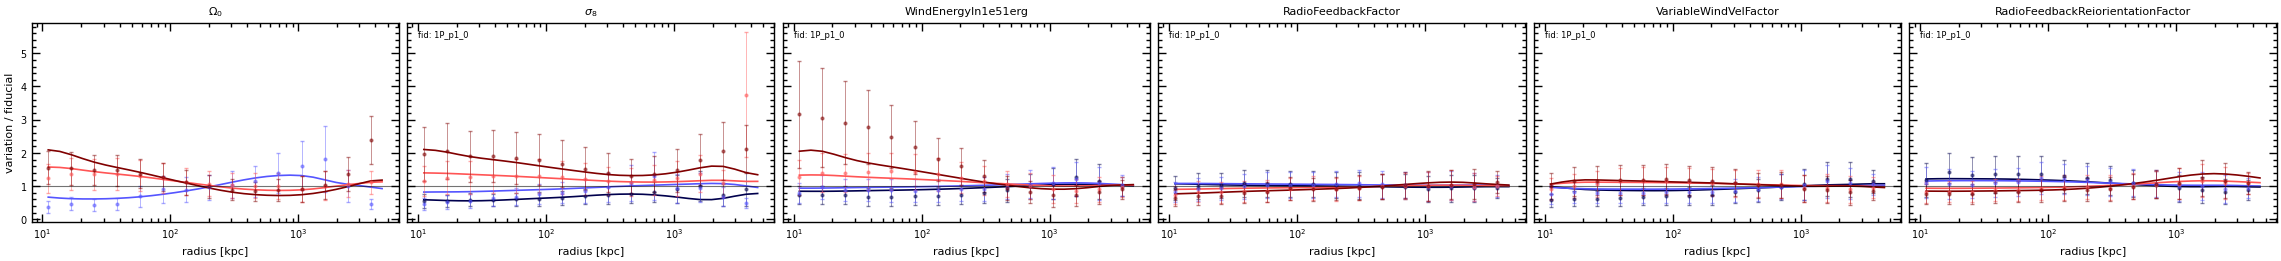

In [14]:
# Quick preview (small) before full 35x5 render.
plot_onep_family_grid(field='pressure', max_rows=6, n_cols=6)

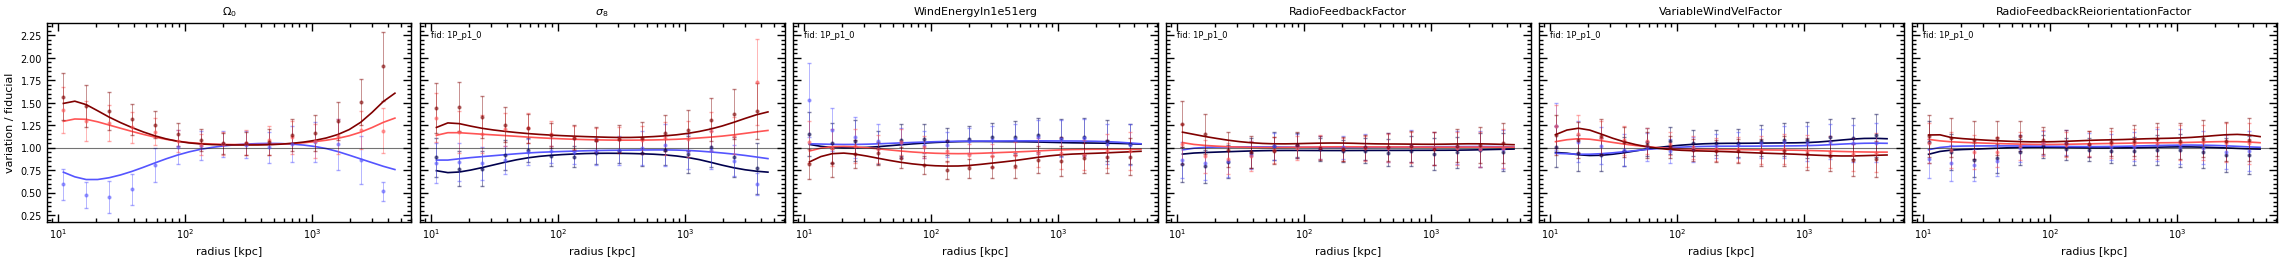

In [15]:
plot_onep_family_grid(field='temperature', max_rows=6, n_cols=6)

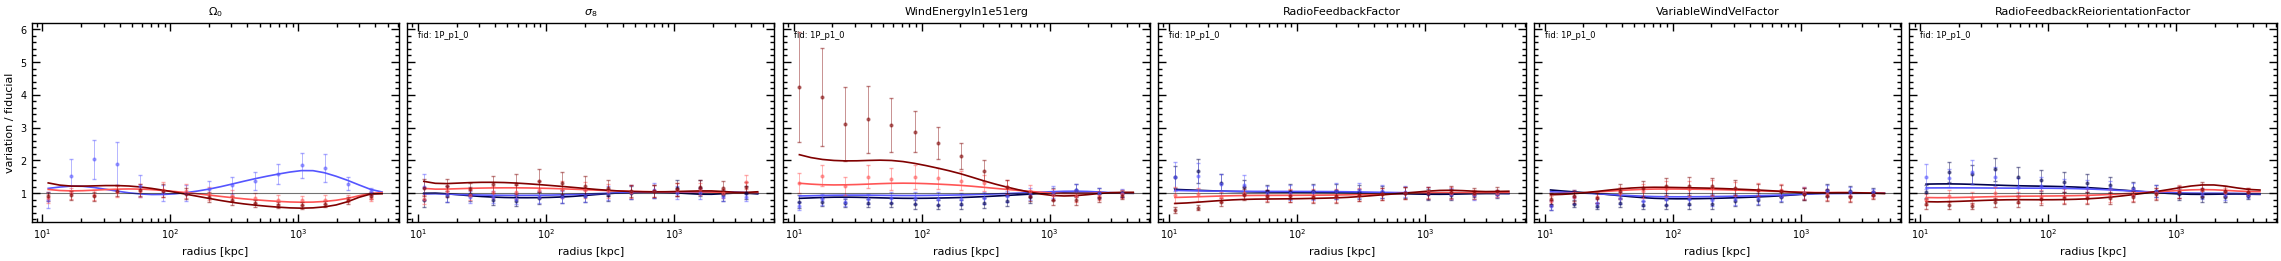

In [16]:
plot_onep_family_grid(field='gas_density', max_rows=6, n_cols=6)

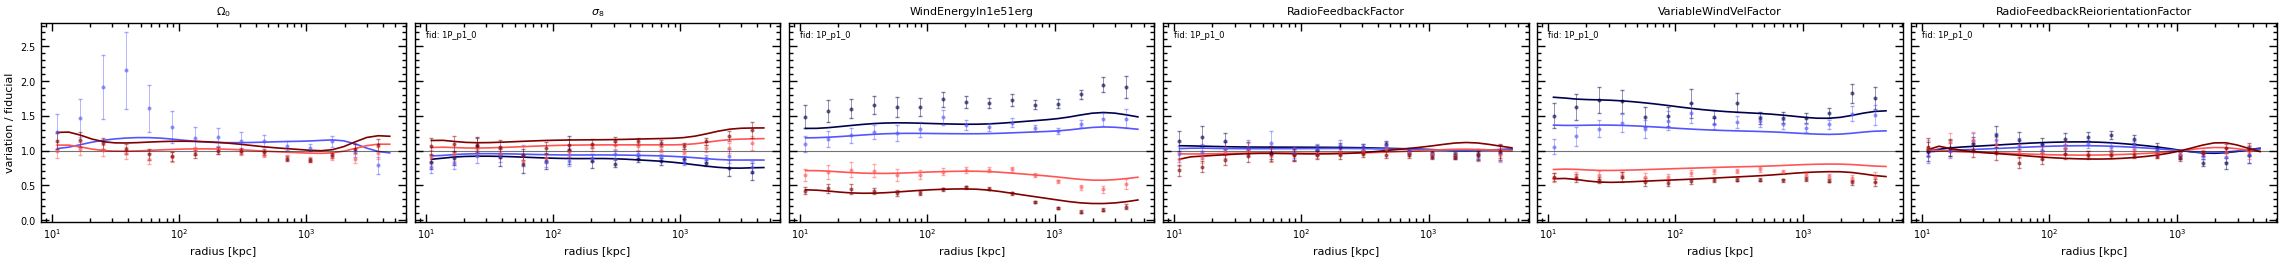

In [17]:
plot_onep_family_grid(field='metallicity', max_rows=6, n_cols=6)

In [18]:
# CV-seed validation setup: compare emulator predictions to fixed-parameter CV realizations.
from pathlib import Path
import re

CV_PROFILE_DIR = Path('Profiles_cy')
CV_SNAPNUM = 90
CV_GLOB = f'IllustrisTNG_CV_*_snap{CV_SNAPNUM:03d}.npz'
CV_FIELDS = ['pressure', 'temperature', 'gas_density']
CV_MASS_CUT = 1e13
CV_NSAMPLES = 30

if not CV_PROFILE_DIR.exists():
    raise FileNotFoundError(f'Profile directory not found: {CV_PROFILE_DIR}')

cv_files = sorted(CV_PROFILE_DIR.glob(CV_GLOB))
if len(cv_files) == 0:
    raise FileNotFoundError(f'No CV files found with pattern: {CV_GLOB}')

cv_tag_pattern = re.compile(r'IllustrisTNG_(CV_\d+)_snap\d+\.npz$')
cv_tag_to_file = {}
for fp in cv_files:
    m = cv_tag_pattern.match(fp.name)
    if m is None:
        continue
    cv_tag_to_file[m.group(1)] = fp

if len(cv_tag_to_file) == 0:
    raise RuntimeError('Could not parse CV tags from file names')

# Resolve fiducial theta used for CV seeds.
FIDUCIAL_TAG = '1P_p1_0'
if 'onep_predictions' in globals() and FIDUCIAL_TAG in onep_predictions:
    theta_fid = np.asarray(onep_predictions[FIDUCIAL_TAG]['theta'], dtype=np.float32)
elif 'onep_params' in globals() and isinstance(onep_params, pd.DataFrame):
    row = onep_params[onep_params['tag'].astype(str) == FIDUCIAL_TAG]
    if len(row) == 0:
        raise KeyError(f'Fiducial tag {FIDUCIAL_TAG} not found in onep_params')
    if 'theta_cols' in globals() and isinstance(theta_cols, list):
        theta_fid = row.iloc[0][theta_cols].to_numpy(dtype=np.float32)
    else:
        num_cols = [
            c for c in row.columns
            if c != 'tag' and pd.api.types.is_numeric_dtype(row[c]) and c.lower() != 'seed'
        ]
        theta_fid = row.iloc[0][num_cols[: emu.theta_dim]].to_numpy(dtype=np.float32)
else:
    raise RuntimeError('Could not resolve fiducial theta; run the 1P setup cells first')

print(f'Found CV files: {len(cv_tag_to_file)}')
print('CV tags:', sorted(cv_tag_to_file.keys()))
print('Fiducial tag source:', FIDUCIAL_TAG)
print('theta_fid shape:', theta_fid.shape)

Found CV files: 27
CV tags: ['CV_0', 'CV_1', 'CV_10', 'CV_11', 'CV_12', 'CV_13', 'CV_14', 'CV_15', 'CV_16', 'CV_17', 'CV_18', 'CV_19', 'CV_2', 'CV_20', 'CV_21', 'CV_22', 'CV_23', 'CV_24', 'CV_25', 'CV_26', 'CV_3', 'CV_4', 'CV_5', 'CV_6', 'CV_7', 'CV_8', 'CV_9']
Fiducial tag source: 1P_p1_0
theta_fid shape: (35,)


In [19]:
# Run emulator on each CV simulation and collect per-halo predictions for all requested fields.
cv_predictions = {}
cv_summary_rows = []

for tag, fp in sorted(cv_tag_to_file.items()):
    with np.load(fp) as dat:
        masses = np.asarray(dat['M500c'], dtype=np.float64)
        r500c = np.asarray(dat['R500c'], dtype=np.float64)
        radial_bins = np.asarray(dat['radial_bins'], dtype=np.float64)

        true_profiles = {}
        for fld in CV_FIELDS:
            key = f'{fld}_array'
            if key not in dat:
                raise KeyError(f'Missing {key} in {fp.name}')
            true_profiles[fld] = np.asarray(dat[key], dtype=np.float64)

    n_halo = masses.shape[0]
    n_r = radial_bins.shape[0]

    # Vectorized per-halo r/R500 grid for one batched emulator call.
    r_bins_rr500 = (
        radial_bins[None, :]
        / np.maximum(r500c[:, None], 1e-12)
    ).astype(np.float32)

    pred = emu.predict(
        theta=theta_fid,
        M=masses.astype(np.float32),
        r_bins=r_bins_rr500,
        field=CV_FIELDS,
        n_samples=CV_NSAMPLES,
    )

    pred_mu = {fld: np.zeros((n_halo, n_r), dtype=np.float64) for fld in CV_FIELDS}
    pred_sd = {fld: np.zeros((n_halo, n_r), dtype=np.float64) for fld in CV_FIELDS}
    for j, fld in enumerate(pred.field_names):
        pred_mu[fld] = np.asarray(pred.mean[:, :, j], dtype=np.float64)
        pred_sd[fld] = np.asarray(pred.total_std[:, :, j], dtype=np.float64)

    cv_predictions[tag] = {
        'file': str(fp),
        'M500c': masses,
        'R500c': r500c,
        'rr500': r_bins_rr500,
        'radial_bins': radial_bins,
        'true_profiles': true_profiles,
        'pred_mu': pred_mu,
        'pred_sd': pred_sd,
    }

    cv_summary_rows.append({
        'tag': tag,
        'n_halos': int(n_halo),
        'n_r': int(n_r),
        'm500c_min': float(np.min(masses)),
        'm500c_median': float(np.median(masses)),
        'm500c_max': float(np.max(masses)),
    })

cv_summary_df = pd.DataFrame(cv_summary_rows).sort_values('tag').reset_index(drop=True)

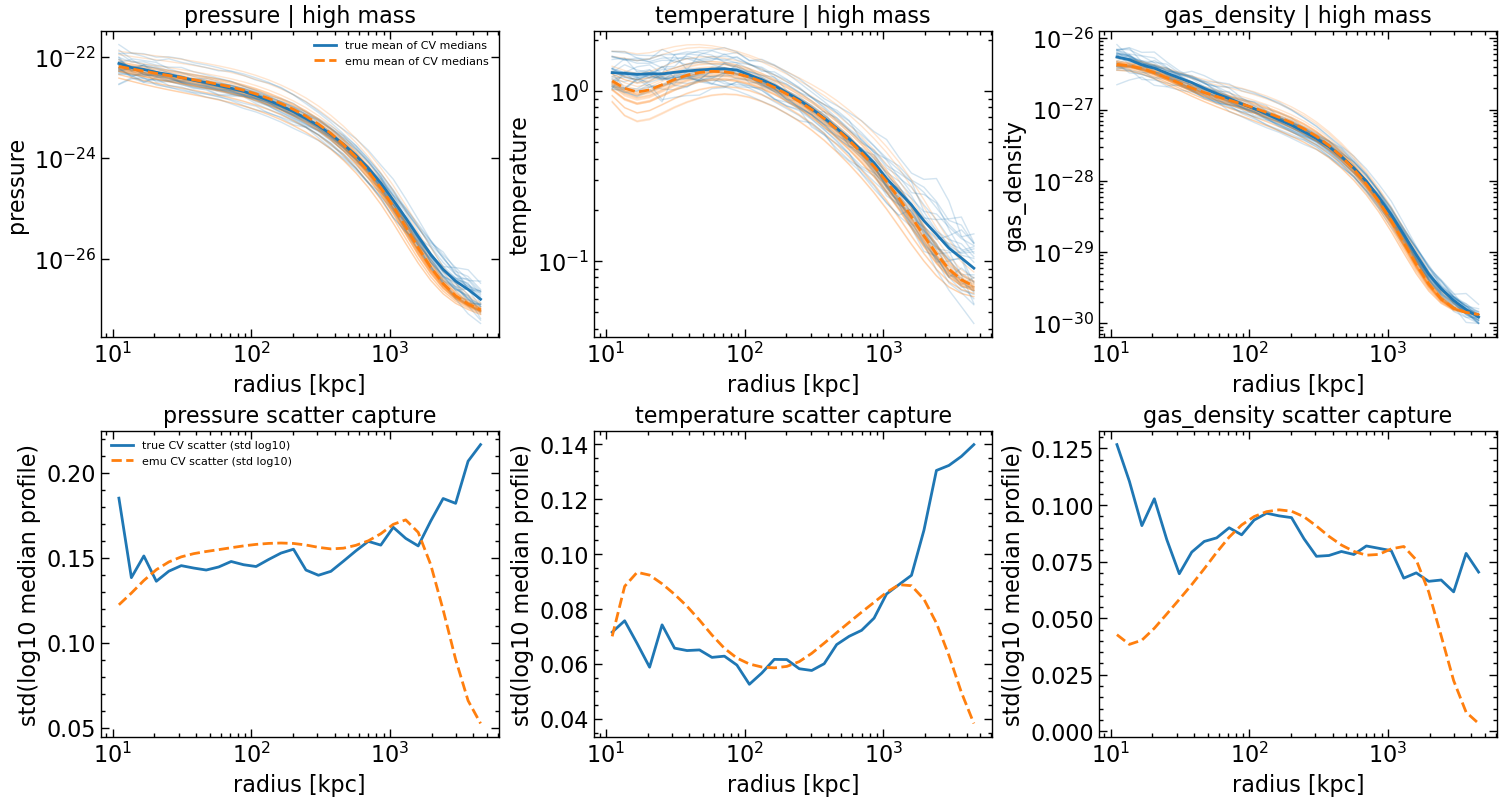

In [20]:
# Visual check: high-mass-only, 3x2 layout (fields as columns).
def plot_cv_scatter_capture_grid(fields=('pressure', 'temperature', 'gas_density'), mass_bin='high'):
    tags = sorted(cv_predictions.keys())
    if len(tags) == 0:
        raise RuntimeError('cv_predictions is empty. Run CV prediction cell first.')

    radial_bins = cv_predictions[tags[0]]['radial_bins']
    fig, axes = plt.subplots(2, len(fields), figsize=(5 * len(fields), 8), constrained_layout=True)
    if len(fields) == 1:
        axes = np.array(axes).reshape(2, 1)

    for col, field in enumerate(fields):
        t_medians = []
        p_medians = []

        for tag in tags:
            rec = cv_predictions[tag]
            mass = rec['M500c']
            if mass_bin == 'low':
                mask = mass < CV_MASS_CUT
            elif mass_bin == 'high':
                mask = mass >= CV_MASS_CUT
            else:
                mask = np.ones_like(mass, dtype=bool)

            if np.sum(mask) == 0:
                continue

            true_arr = np.clip(rec['true_profiles'][field][mask], 1e-30, None)
            pred_arr = np.clip(rec['pred_mu'][field][mask], 1e-30, None)

            t_medians.append(np.median(true_arr, axis=0))
            p_medians.append(np.median(pred_arr, axis=0))

        ax_top = axes[0, col]
        ax_bot = axes[1, col]

        if len(t_medians) < 2:
            ax_top.text(0.5, 0.5, 'Need >=2 CV runs', ha='center', va='center', transform=ax_top.transAxes)
            ax_bot.text(0.5, 0.5, 'Need >=2 CV runs', ha='center', va='center', transform=ax_bot.transAxes)
            ax_top.set_title(f'{field} | {mass_bin} mass')
            continue

        t_medians = np.asarray(t_medians)
        p_medians = np.asarray(p_medians)

        t_mean = np.mean(t_medians, axis=0)
        p_mean = np.mean(p_medians, axis=0)
        t_scatter = np.std(np.log10(t_medians), axis=0, ddof=1)
        p_scatter = np.std(np.log10(p_medians), axis=0, ddof=1)

        # Top row: profile overlays + means.
        for i in range(t_medians.shape[0]):
            ax_top.plot(radial_bins, t_medians[i], color='tab:blue', alpha=0.2, lw=1.0)
            ax_top.plot(radial_bins, p_medians[i], color='tab:orange', alpha=0.2, lw=1.0)
        ax_top.plot(radial_bins, t_mean, color='tab:blue', lw=2.0, label='true mean of CV medians')
        ax_top.plot(radial_bins, p_mean, color='tab:orange', lw=2.0, ls='--', label='emu mean of CV medians')
        ax_top.set_xscale('log')
        ax_top.set_yscale('log')
        ax_top.set_xlabel('radius [kpc]')
        ax_top.set_ylabel(field)
        ax_top.set_title(f'{field} | {mass_bin} mass')
        if col == 0:
            ax_top.legend(fontsize=8)

        # Bottom row: scatter capture only (no ratio line).
        ax_bot.plot(radial_bins, t_scatter, color='tab:blue', lw=2.0, label='true CV scatter (std log10)')
        ax_bot.plot(radial_bins, p_scatter, color='tab:orange', lw=2.0, ls='--', label='emu CV scatter (std log10)')
        ax_bot.set_xscale('log')
        ax_bot.set_xlabel('radius [kpc]')
        ax_bot.set_ylabel('std(log10 median profile)')
        ax_bot.set_title(f'{field} scatter capture')
        if col == 0:
            ax_bot.legend(fontsize=8)

    plt.show()


plot_cv_scatter_capture_grid(fields=('pressure', 'temperature', 'gas_density'), mass_bin='high')

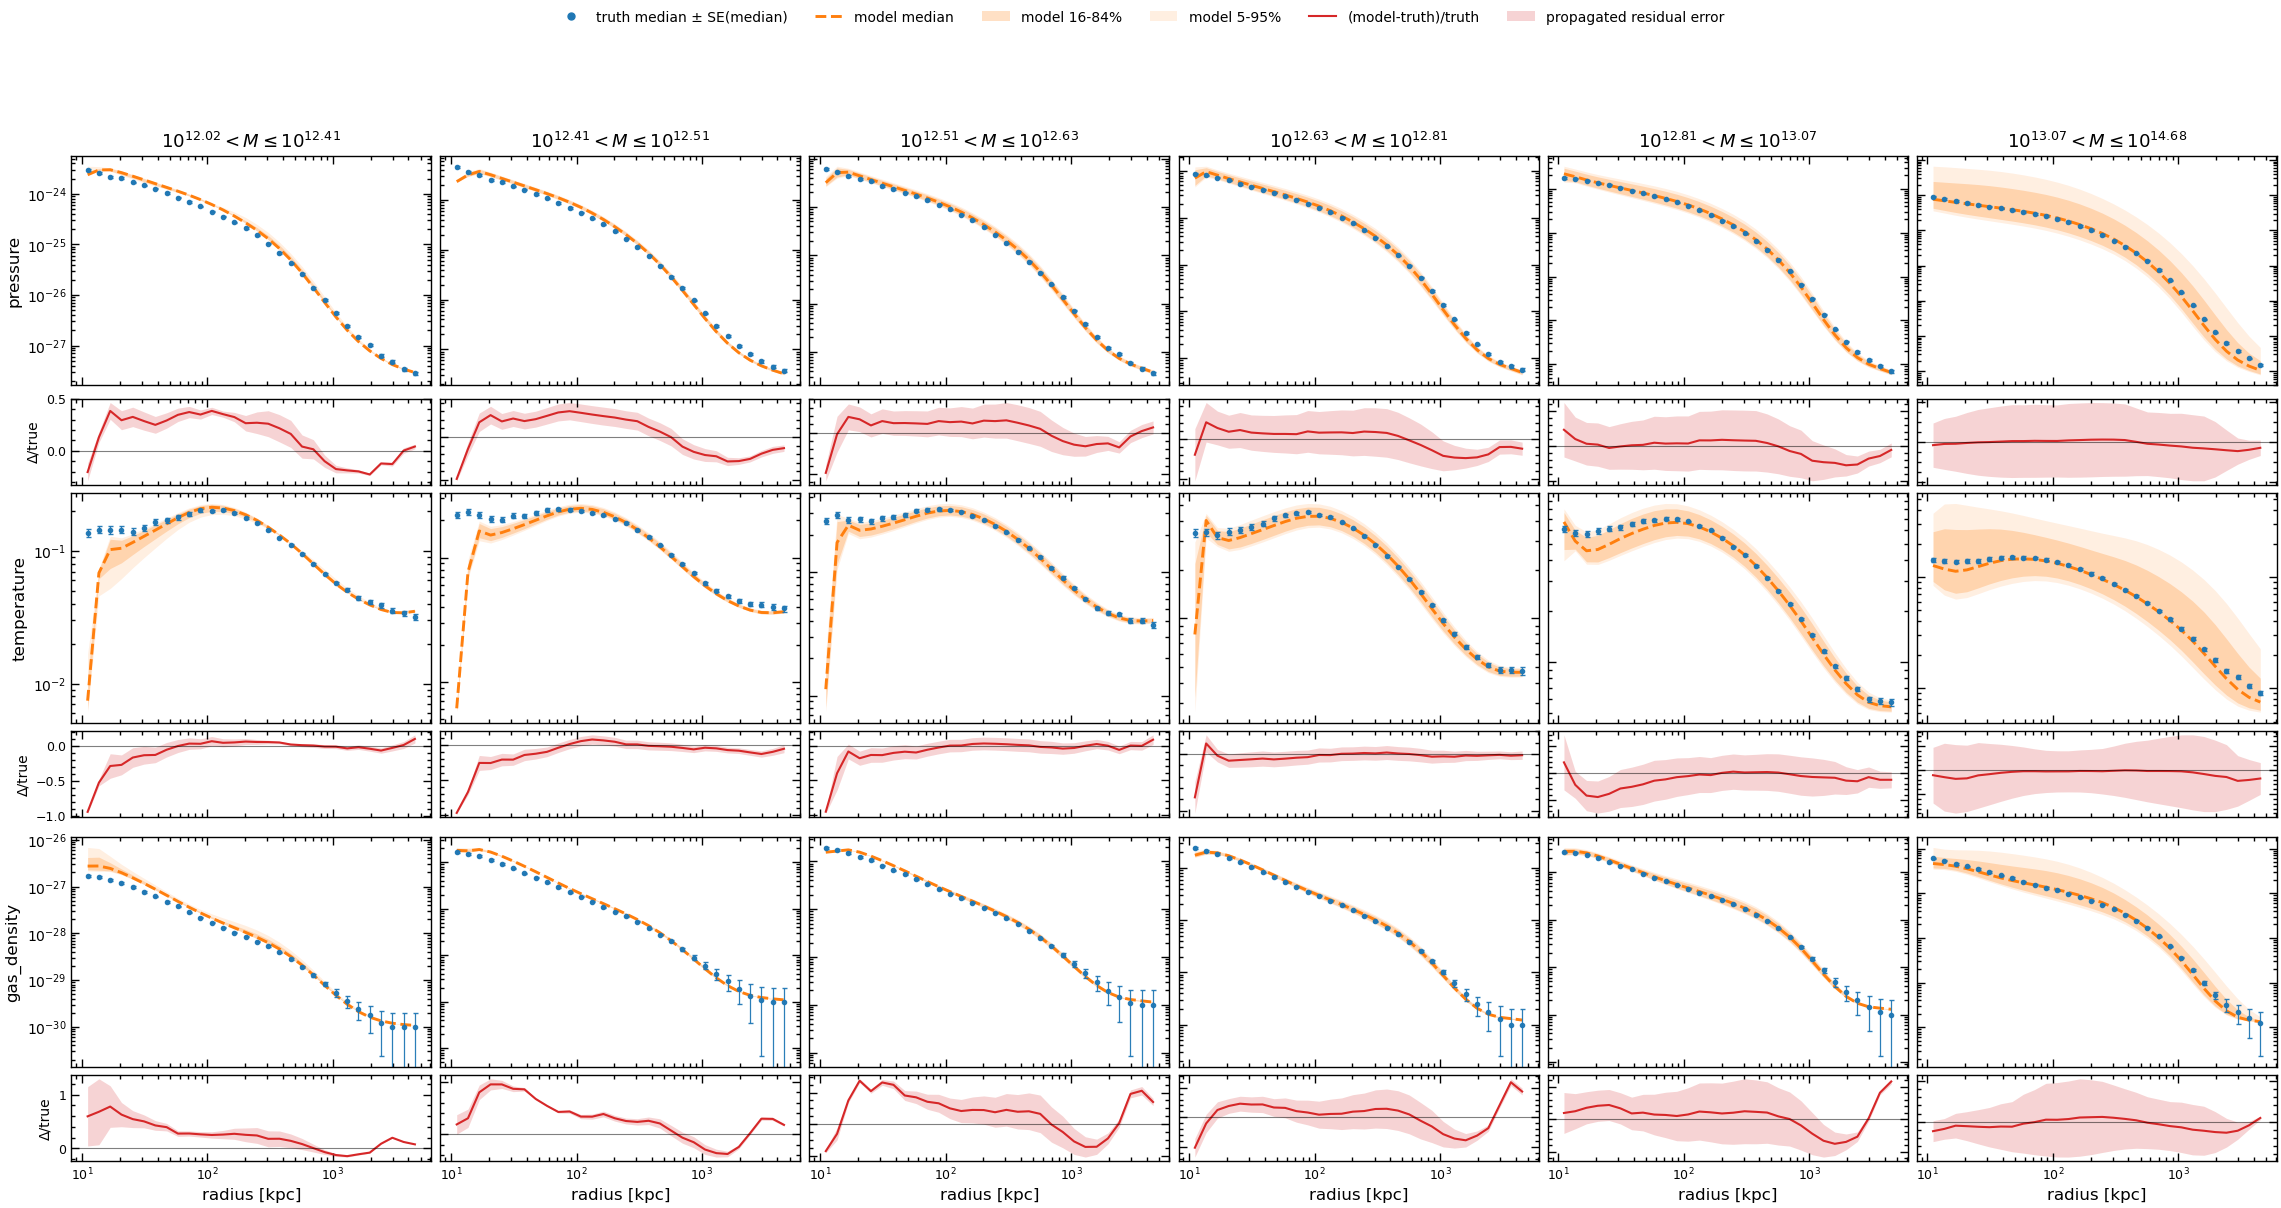

Quantile-based non-linear binning with 6 bins; plotted bins satisfy N >= 20.
Mass-bin median match summary (valid_n marks bins passing the N threshold):


,field,mass_bin,n_halos,valid_n,median_abs_log10_resid,median_abs_rel_diff_pct
0,gas_density,10^12.02-10^12.41,509,True,0.094760,24.383430
1,gas_density,10^12.41-10^12.51,509,True,0.064794,15.337965
2,gas_density,10^12.51-10^12.63,508,True,0.051616,11.977776
3,gas_density,10^12.63-10^12.81,509,True,0.033965,7.861871
4,gas_density,10^12.81-10^13.07,509,True,0.023602,5.584988
5,gas_density,10^13.07-10^14.68,509,True,0.046591,10.949889
6,pressure,10^12.02-10^12.41,509,True,0.099728,23.782757
7,pressure,10^12.41-10^12.51,509,True,0.086495,20.819032
8,pressure,10^12.51-10^12.63,508,True,0.050518,12.336332
9,pressure,10^12.63-10^12.81,509,True,0.036637,8.802009


In [21]:
# CV mass-bin median-profile validation across all halos.
def plot_cv_massbin_median_match(
    fields=('pressure', 'temperature', 'gas_density'),
    logm_start=12.0,
    n_mass_bins=6,
    min_count_per_bin=20,
    eps=1e-30,
):
    tags = sorted(cv_predictions.keys())
    if len(tags) == 0:
        raise RuntimeError('cv_predictions is empty. Run CV prediction cell first.')

    # Gather all halo masses and build 6 non-linear bins via quantiles.
    all_logm = []
    for tag in tags:
        m = np.asarray(cv_predictions[tag]['M500c'], dtype=np.float64)
        all_logm.append(np.log10(np.clip(m, 1e-30, None)))
    all_logm = np.concatenate(all_logm)

    pool = all_logm[all_logm >= float(logm_start)]
    if pool.size < max(2, n_mass_bins):
        pool = all_logm.copy()

    q = np.linspace(0.0, 1.0, int(n_mass_bins) + 1)
    edges = np.quantile(pool, q)
    edges = np.unique(edges)

    # Fallback to linear spacing if quantiles collapse due to repeated values.
    if edges.size < int(n_mass_bins) + 1:
        lo = max(float(logm_start), float(np.nanmin(all_logm)))
        hi = float(np.nanmax(all_logm))
        if hi <= lo:
            hi = lo + 0.2
        edges = np.linspace(lo, hi, int(n_mass_bins) + 1)

    n_bins = len(edges) - 1
    labels = []
    for i in range(n_bins):
        labels.append(f'10^{edges[i]:.2f}-10^{edges[i+1]:.2f}')

    # Radial-grid consistency check across CV runs.
    radial_ref = np.asarray(cv_predictions[tags[0]]['radial_bins'], dtype=np.float64)
    for tag in tags[1:]:
        rb = np.asarray(cv_predictions[tag]['radial_bins'], dtype=np.float64)
        if rb.shape != radial_ref.shape or not np.allclose(rb, radial_ref, rtol=1e-6, atol=1e-12):
            raise ValueError(f'Radial bins mismatch for tag {tag}; expected common grid for bin medians.')

    # Total halo count per bin (shared across fields).
    bin_counts = {}
    for i_bin, label in enumerate(labels):
        lo, hi = edges[i_bin], edges[i_bin + 1]
        if i_bin < len(labels) - 1:
            sel = (all_logm >= lo) & (all_logm < hi)
        else:
            sel = (all_logm >= lo) & (all_logm <= hi)
        bin_counts[label] = int(np.sum(sel))

    medians = {fld: {} for fld in fields}
    summary_rows = []

    for i_bin, bin_label in enumerate(labels):
        lo, hi = edges[i_bin], edges[i_bin + 1]

        for fld in fields:
            true_stack = []
            pred_stack = []

            for tag in tags:
                rec = cv_predictions[tag]
                mass = np.asarray(rec['M500c'], dtype=np.float64)
                logm = np.log10(np.clip(mass, 1e-30, None))

                if i_bin < len(labels) - 1:
                    mask = (logm >= lo) & (logm < hi)
                else:
                    mask = (logm >= lo) & (logm <= hi)

                if not np.any(mask):
                    continue

                true_arr = np.asarray(rec['true_profiles'][fld], dtype=np.float64)[mask]
                pred_arr = np.asarray(rec['pred_mu'][fld], dtype=np.float64)[mask]
                true_stack.append(true_arr)
                pred_stack.append(pred_arr)

            n_halos = int(bin_counts[bin_label])
            is_valid = n_halos >= int(min_count_per_bin)

            if len(true_stack) == 0:
                medians[fld][bin_label] = None
                summary_rows.append({
                    'field': fld,
                    'mass_bin': bin_label,
                    'n_halos': n_halos,
                    'valid_n': bool(is_valid),
                    'median_abs_log10_resid': np.nan,
                    'median_abs_rel_diff_pct': np.nan,
                })
                continue

            true_stack = np.vstack(true_stack)
            pred_stack = np.vstack(pred_stack)

            true_clip = np.clip(true_stack, eps, None)
            pred_clip = np.clip(pred_stack, eps, None)

            true_med = np.median(true_clip, axis=0)
            pred_med = np.median(pred_clip, axis=0)

            # Approximate SE of median per radius from robust scatter.
            mad = np.median(np.abs(true_clip - true_med[None, :]), axis=0)
            sigma_rob = 1.4826 * mad
            true_med_err = 1.2533 * sigma_rob / np.sqrt(max(n_halos, 1))

            # Model contour bands from halo-to-halo spread in emulator medians.
            pred_q16 = np.quantile(pred_clip, 0.16, axis=0)
            pred_q84 = np.quantile(pred_clip, 0.84, axis=0)
            pred_q05 = np.quantile(pred_clip, 0.05, axis=0)
            pred_q95 = np.quantile(pred_clip, 0.95, axis=0)

            log_resid = np.log10(np.clip(pred_med, eps, None)) - np.log10(np.clip(true_med, eps, None))
            rel_diff = (pred_med - true_med) / np.clip(true_med, eps, None)

            medians[fld][bin_label] = {
                'true_med': true_med,
                'true_med_err': np.clip(true_med_err, 0.0, None),
                'pred_med': pred_med,
                'pred_q16': pred_q16,
                'pred_q84': pred_q84,
                'pred_q05': pred_q05,
                'pred_q95': pred_q95,
                'n_halos': n_halos,
                'valid_n': bool(is_valid),
                'median_abs_log10_resid': float(np.median(np.abs(log_resid))),
                'median_abs_rel_diff_pct': float(100.0 * np.median(np.abs(rel_diff))),
            }

            summary_rows.append({
                'field': fld,
                'mass_bin': bin_label,
                'n_halos': n_halos,
                'valid_n': bool(is_valid),
                'median_abs_log10_resid': float(np.median(np.abs(log_resid))),
                'median_abs_rel_diff_pct': float(100.0 * np.median(np.abs(rel_diff))),
            })

    summary_df = pd.DataFrame(summary_rows)
    valid_labels = [lab for lab in labels if bin_counts[lab] >= int(min_count_per_bin)]

    if len(valid_labels) == 0:
        print(f'No bins satisfy N >= {min_count_per_bin}.')
        print('Mass-bin summary (including underpopulated bins):')
        display(summary_df.sort_values(['field', 'mass_bin']).reset_index(drop=True))
        return summary_df, medians, edges

    # Styling knobs for presentation readability.
    title_fs = 13
    label_fs = 12
    tick_fs = 10

    # For each field, make a main row + a shorter residual row.
    n_fields = len(fields)
    n_cols = len(valid_labels)
    n_rows_total = 2 * n_fields
    height_ratios = []
    for _ in range(n_fields):
        height_ratios.extend([3.2, 1.2])

    fig, axes = plt.subplots(
        n_rows_total,
        n_cols,
        figsize=(3.8 * n_cols, 3.6 * n_fields),
        constrained_layout=True,
        sharex='col',
        gridspec_kw={'height_ratios': height_ratios},
    )

    if n_rows_total == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows_total == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array(axes).reshape(n_rows_total, 1)

    for j_col, bin_label in enumerate(valid_labels):
        lo = edges[labels.index(bin_label)]
        hi = edges[labels.index(bin_label) + 1]

        # Only top row gets mass-range title in LaTeX.
        axes[0, j_col].set_title(rf'$10^{{{lo:.2f}}} < M \leq 10^{{{hi:.2f}}}$', fontsize=title_fs)

        for i_fld, fld in enumerate(fields):
            ax_main = axes[2 * i_fld, j_col]
            ax_res = axes[2 * i_fld + 1, j_col]
            rec = medians[fld][bin_label]

            if rec is None:
                ax_main.text(0.5, 0.5, 'No halos', ha='center', va='center', transform=ax_main.transAxes)
                ax_main.set_xscale('log')
                ax_main.set_yscale('log')
                ax_res.set_xscale('log')
                ax_res.axhline(0.0, color='k', lw=0.8, alpha=0.4)
                continue

            true_med = rec['true_med']
            true_med_err = np.clip(rec['true_med_err'], 1e-30, None)
            pred_med = rec['pred_med']
            pred_q16 = np.clip(rec['pred_q16'], eps, None)
            pred_q84 = np.clip(rec['pred_q84'], eps, None)
            pred_q05 = np.clip(rec['pred_q05'], eps, None)
            pred_q95 = np.clip(rec['pred_q95'], eps, None)

            # Model contours.
            ax_main.fill_between(radial_ref, pred_q05, pred_q95, color='tab:orange', alpha=0.12, linewidth=0)
            ax_main.fill_between(radial_ref, pred_q16, pred_q84, color='tab:orange', alpha=0.24, linewidth=0)
            ax_main.plot(radial_ref, pred_med, color='tab:orange', lw=2.1, ls='--')

            # Truth points with error bars.
            step = max(1, radial_ref.size // 16)
            idx = np.arange(0, radial_ref.size, step)
            ax_main.errorbar(
                radial_ref[idx],
                true_med[idx],
                yerr=true_med_err[idx],
                fmt='o',
                ms=3.0,
                lw=0.9,
                elinewidth=0.9,
                capsize=1.8,
                color='tab:blue',
                alpha=0.95,
            )

            # Residual panel: relative difference with propagated uncertainty.
            sigma_model = 0.5 * (pred_q84 - pred_q16)
            denom = np.clip(true_med, eps, None)
            rel = (pred_med - true_med) / denom
            rel_sigma = np.sqrt((sigma_model / denom) ** 2 + ((pred_med * true_med_err) / np.clip(denom**2, eps, None)) ** 2)

            ax_res.plot(radial_ref, rel, color='tab:red', lw=1.5)
            ax_res.fill_between(radial_ref, rel - rel_sigma, rel + rel_sigma, color='tab:red', alpha=0.2, linewidth=0)
            ax_res.axhline(0.0, color='k', lw=0.8, alpha=0.5)

            ax_main.set_xscale('log')
            ax_main.set_yscale('log')
            ax_res.set_xscale('log')
            ax_main.tick_params(axis='both', which='both', labelsize=tick_fs)
            ax_res.tick_params(axis='both', which='both', labelsize=max(8, tick_fs - 1))

            # Y-axis formatting and clutter control.
            if j_col == 0:
                ax_main.set_ylabel(fld, fontsize=label_fs)
                ax_res.set_ylabel('Δ/true', fontsize=max(9, label_fs - 2))
                ax_main.tick_params(labelleft=True)
                ax_res.tick_params(labelleft=True)
            else:
                ax_main.set_ylabel('')
                ax_res.set_ylabel('')
                ax_main.tick_params(labelleft=False)
                ax_res.tick_params(labelleft=False)

            # Only bottom residual row gets x-label.
            if i_fld == n_fields - 1:
                ax_res.set_xlabel('radius [kpc]', fontsize=label_fs)

    # One clean legend outside the plotting area (above the figure).
    legend_handles = [
        plt.Line2D([0], [0], color='tab:blue', marker='o', linestyle='None', markersize=5, label='truth median ± SE(median)'),
        plt.Line2D([0], [0], color='tab:orange', lw=2.1, ls='--', label='model median'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.24, label='model 16-84%'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.12, label='model 5-95%'),
        plt.Line2D([0], [0], color='tab:red', lw=1.5, label='(model-truth)/truth'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:red', alpha=0.2, label='propagated residual error'),
    ]
    fig.legend(
        handles=legend_handles,
        loc='upper center',
        ncol=6,
        frameon=False,
        bbox_to_anchor=(0.5, 1.12),
        fontsize=10,
    )

    plt.show()

    print(f'Quantile-based non-linear binning with {n_mass_bins} bins; plotted bins satisfy N >= {min_count_per_bin}.')
    print('Mass-bin median match summary (valid_n marks bins passing the N threshold):')
    display(summary_df.sort_values(['field', 'mass_bin']).reset_index(drop=True))

    return summary_df, medians, edges


cv_massbin_summary_df, cv_massbin_medians, cv_massbin_edges = plot_cv_massbin_median_match(
    fields=('pressure', 'temperature', 'gas_density'),
    logm_start=12.0,
    n_mass_bins=6,
    min_count_per_bin=20,
)


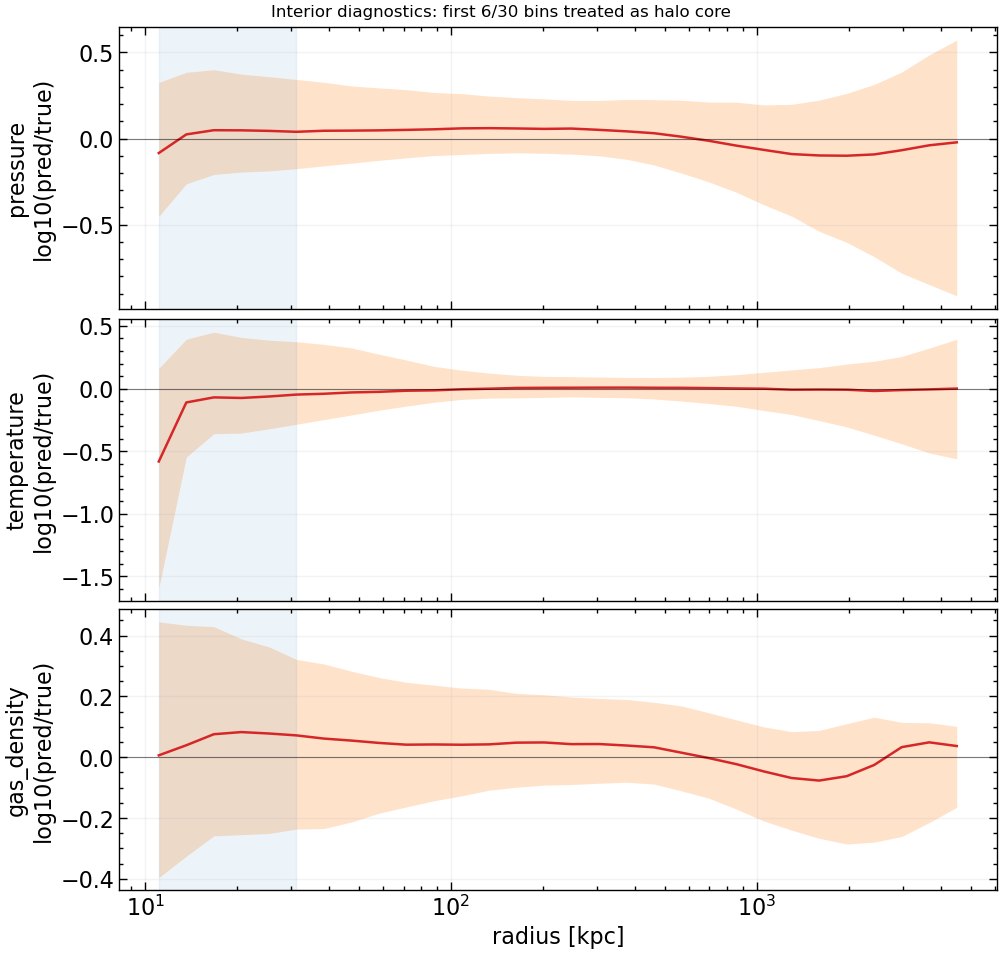

,field,n_halos,n_r,n_core,core_abs_log10_resid_med,outer_abs_log10_resid_med,core_to_outer_abs_log10_ratio,core_abs_rel_pct_med,outer_abs_rel_pct_med,core_signed_rel_pct_med,outer_signed_rel_pct_med,mass_bin
0,gas_density,611,30,6,0.328759,0.146025,2.251392,79.590913,40.152348,65.418100,16.460088,10^12.02-10^12.43
1,gas_density,610,30,6,0.267649,0.135160,1.980238,59.646007,35.801797,23.388261,7.595185,10^12.43-10^12.55
2,gas_density,611,30,6,0.236385,0.115788,2.041525,52.564963,30.139056,6.299164,4.531766,10^12.55-10^12.73
3,gas_density,610,30,6,0.202203,0.099668,2.028774,45.337346,23.248127,8.167950,1.814705,10^12.73-10^13.00
4,gas_density,611,30,6,0.161300,0.074116,2.176308,36.640193,17.095429,0.757131,1.000141,10^13.00-10^14.68
5,gas_density,3053,30,6,0.228505,0.109500,2.086807,51.918308,27.891809,15.364177,4.734663,NaN
6,pressure,611,30,6,0.250128,0.230643,1.084484,54.685865,52.802370,19.276603,17.670082,10^12.02-10^12.43
7,pressure,610,30,6,0.240252,0.205499,1.169113,50.962557,47.062271,2.339121,6.503674,10^12.43-10^12.55
8,pressure,611,30,6,0.197889,0.168872,1.171828,42.242990,38.400014,5.110613,3.852474,10^12.55-10^12.73
9,pressure,610,30,6,0.166162,0.133917,1.240778,36.119392,30.245241,6.172134,0.873663,10^12.73-10^13.00



Overall (all masses pooled):


,field,n_halos,n_core,core_abs_log10_resid_med,outer_abs_log10_resid_med,core_to_outer_abs_log10_ratio,core_signed_rel_pct_med,outer_signed_rel_pct_med
0,pressure,3053,6,0.191723,0.159694,1.200564,6.108224,4.961887
6,temperature,3053,6,0.282365,0.096326,2.931358,-21.465040,-0.445210
12,gas_density,3053,6,0.228505,0.109500,2.086807,15.364177,4.734663


In [22]:
# Interior-vs-outer diagnostic for CV predictions.
def diagnose_cv_core_bias(
    cv_predictions,
    fields=("pressure", "temperature", "gas_density"),
    core_frac=0.2,
    core_min_bins=3,
    eps=1e-30,
    n_mass_bins=5,
):
    tags = sorted(cv_predictions.keys())
    if not tags:
        raise RuntimeError("cv_predictions is empty")

    rb = np.asarray(cv_predictions[tags[0]]["radial_bins"], dtype=np.float64)
    for tag in tags[1:]:
        rb_i = np.asarray(cv_predictions[tag]["radial_bins"], dtype=np.float64)
        if rb_i.shape != rb.shape or not np.allclose(rb_i, rb, rtol=1e-6, atol=1e-12):
            raise ValueError(f"Radial bins mismatch for tag={tag}")

    n_r = int(rb.size)
    n_core = min(n_r, max(int(core_min_bins), int(np.ceil(float(core_frac) * n_r))))

    rows = []
    fig, axes = plt.subplots(len(fields), 1, figsize=(10, 3.1 * len(fields)), sharex=True, constrained_layout=True)
    if len(fields) == 1:
        axes = [axes]

    for i, fld in enumerate(fields):
        true_all = []
        pred_all = []
        mass_all = []

        for tag in tags:
            rec = cv_predictions[tag]
            t = np.asarray(rec["true_profiles"][fld], dtype=np.float64)
            p = np.asarray(rec["pred_mu"][fld], dtype=np.float64)
            m = np.asarray(rec["M500c"], dtype=np.float64)
            true_all.append(t)
            pred_all.append(p)
            mass_all.append(m)

        yt = np.vstack(true_all)
        yp = np.vstack(pred_all)
        m500 = np.concatenate(mass_all)

        yt_clip = np.clip(yt, eps, None)
        yp_clip = np.clip(yp, eps, None)

        log_res = np.log10(yp_clip) - np.log10(yt_clip)
        rel = (yp - yt) / np.clip(np.abs(yt), eps, None)

        core = slice(0, n_core)
        outer = slice(n_core, n_r)

        core_med_abs_log = float(np.median(np.abs(log_res[:, core])))
        core_med_abs_rel = float(100.0 * np.median(np.abs(rel[:, core])))
        core_med_signed_rel = float(100.0 * np.median(rel[:, core]))

        if n_core < n_r:
            outer_med_abs_log = float(np.median(np.abs(log_res[:, outer])))
            outer_med_abs_rel = float(100.0 * np.median(np.abs(rel[:, outer])))
            outer_med_signed_rel = float(100.0 * np.median(rel[:, outer]))
        else:
            outer_med_abs_log = np.nan
            outer_med_abs_rel = np.nan
            outer_med_signed_rel = np.nan

        rows.append({
            "field": fld,
            "n_halos": int(yt.shape[0]),
            "n_r": n_r,
            "n_core": n_core,
            "core_abs_log10_resid_med": core_med_abs_log,
            "outer_abs_log10_resid_med": outer_med_abs_log,
            "core_to_outer_abs_log10_ratio": float(core_med_abs_log / max(outer_med_abs_log, 1e-12)) if np.isfinite(outer_med_abs_log) else np.nan,
            "core_abs_rel_pct_med": core_med_abs_rel,
            "outer_abs_rel_pct_med": outer_med_abs_rel,
            "core_signed_rel_pct_med": core_med_signed_rel,
            "outer_signed_rel_pct_med": outer_med_signed_rel,
        })

        ax = axes[i]
        p16 = np.percentile(log_res, 16, axis=0)
        p50 = np.percentile(log_res, 50, axis=0)
        p84 = np.percentile(log_res, 84, axis=0)
        ax.fill_between(rb, p16, p84, alpha=0.22, color="tab:orange", linewidth=0)
        ax.plot(rb, p50, color="tab:red", lw=1.8)
        ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
        if n_core < n_r:
            ax.axvspan(rb[0], rb[n_core - 1], color="tab:blue", alpha=0.08)
        ax.set_xscale("log")
        ax.set_ylabel(f"{fld}\nlog10(pred/true)")
        ax.grid(alpha=0.15)

        # Mass-bin interior diagnostics for this field.
        logm = np.log10(np.clip(m500, 1e-30, None))
        q = np.linspace(0.0, 1.0, int(n_mass_bins) + 1)
        edges = np.unique(np.quantile(logm, q))
        for j in range(max(0, len(edges) - 1)):
            lo, hi = edges[j], edges[j + 1]
            if j < len(edges) - 2:
                sel = (logm >= lo) & (logm < hi)
            else:
                sel = (logm >= lo) & (logm <= hi)
            if int(np.sum(sel)) < 10:
                continue
            rows.append({
                "field": fld,
                "mass_bin": f"10^{lo:.2f}-10^{hi:.2f}",
                "n_halos": int(np.sum(sel)),
                "n_r": n_r,
                "n_core": n_core,
                "core_abs_log10_resid_med": float(np.median(np.abs(log_res[sel, core]))),
                "outer_abs_log10_resid_med": float(np.median(np.abs(log_res[sel, outer]))) if n_core < n_r else np.nan,
                "core_to_outer_abs_log10_ratio": float(np.median(np.abs(log_res[sel, core])) / max(np.median(np.abs(log_res[sel, outer])), 1e-12)) if n_core < n_r else np.nan,
                "core_abs_rel_pct_med": float(100.0 * np.median(np.abs(rel[sel, core]))),
                "outer_abs_rel_pct_med": float(100.0 * np.median(np.abs(rel[sel, outer]))) if n_core < n_r else np.nan,
                "core_signed_rel_pct_med": float(100.0 * np.median(rel[sel, core])),
                "outer_signed_rel_pct_med": float(100.0 * np.median(rel[sel, outer])) if n_core < n_r else np.nan,
            })

    axes[-1].set_xlabel("radius [kpc]")
    fig.suptitle(f"Interior diagnostics: first {n_core}/{n_r} bins treated as halo core", y=1.02)
    plt.show()

    diag_df = pd.DataFrame(rows)
    display(diag_df.sort_values(["field", "mass_bin"] if "mass_bin" in diag_df.columns else ["field"]).reset_index(drop=True))

    overall = diag_df[diag_df.get("mass_bin", pd.Series([np.nan] * len(diag_df))).isna()].copy()
    print("\nOverall (all masses pooled):")
    display(overall[[
        "field",
        "n_halos",
        "n_core",
        "core_abs_log10_resid_med",
        "outer_abs_log10_resid_med",
        "core_to_outer_abs_log10_ratio",
        "core_signed_rel_pct_med",
        "outer_signed_rel_pct_med",
    ]])

    return diag_df


cv_core_diag_df = diagnose_cv_core_bias(
    cv_predictions,
    fields=("pressure", "temperature", "gas_density"),
    core_frac=0.2,
    core_min_bins=3,
    n_mass_bins=5,
)
